# AMLDL (MBA ZG582) - Assignment 2
## Phase 2: Machine Learning Phase

**Project:** Bike-Buyer Propensity Modelling for Adventure Works Cycles
**Dataset:** Microsoft AdventureWorks customer data (EdX DAT275x lab extract)
**Files:** `AdvWorksCusts.csv` + `AW_BikeBuyer.csv` + `AW_AveMonthSpend.csv`
**Scope:** 16,404 unique customers across 6 countries, 23 modelling features

### Student Details

| Name | BITS ID | Contribution |
|---|---|---|
| Sangitha V | 2024BC26670 | 100% |

---

### Problem statement

Adventure Works Cycles runs direct marketing campaigns to sell bicycles. Mailing
the entire customer base wastes budget on people who will never buy; mailing too
narrowly leaves revenue on the table. The business needs to know **which
customers to contact**.

**ML framing - supervised binary classification.** Predict `BikeBuyer`, whether a
customer has purchased a bike, from demographic and household attributes. The
model's real output is not a yes/no label but a **ranked propensity score**, which
the campaign cuts at whatever depth the budget allows.

| | |
|---|---|
| **Target** | `BikeBuyer` - binary, 33.25% positive |
| **Unit of analysis** | one customer |
| **Class balance** | 1 : 2.01 (moderate imbalance) |
| **Primary metric** | ROC-AUC - scores the ranking, independent of cut-off |
| **Secondary metrics** | F1, PR-AUC, precision, recall, balanced accuracy |
| **Baselines** | majority-class and stratified-random classifiers |

---

### Assignment-2 task coverage

| # | Task from the brief | Where |
|---|---|---|
| 1 | Prepare dataset (feature selection, encoding) | Steps 1-2 |
| 2 | Train selected models | Step 4 |
| 3 | Evaluate with appropriate metrics | Steps 4, 8, 9 |
| 4 | Hyperparameter tuning (random search / validation curves) | Step 5 |
| 5 | Compare performance, justify final selection | Step 8 |
| 6 | Dimensionality reduction (PCA) and ensembles | Steps 6-7 |
| 7 | Methodology, results, plots, business interpretation | throughout, Step 10 |

---

### Why classification, and why this dataset

The business decision is a **contact / do-not-contact** choice over a fixed
customer list, which is a classification problem by construction. The dataset
also carries genuine preparation work - duplicate records with conflicting
values, a whitespace defect in a category level, an ordinal variable that should
not be one-hot encoded, and a leakage trap in `AveMonthSpend` - so Step 1 is real
analysis rather than a formality.


---
## Environment setup

Run this first - it fetches the three CSVs straight from the public GitHub mirror, so the notebook is self-contained on Colab.

In [1]:
# --- Colab / local data setup -----------------------------------------------
# Downloads the three AdventureWorks CSVs if they are not already present.
import os
import urllib.request

DATA_DIR = os.path.join("data", "adventureworks")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

BASE = "https://raw.githubusercontent.com/kdavenpo/AdventureWorks/master/"
for fn in ["AdvWorksCusts.csv", "AW_BikeBuyer.csv", "AW_AveMonthSpend.csv"]:
    dest = os.path.join(DATA_DIR, fn)
    if not os.path.exists(dest):
        print("downloading", fn)
        urllib.request.urlretrieve(BASE + fn, dest)
    print(f"{fn:24s} ready ({os.path.getsize(dest):,} bytes)")

AdvWorksCusts.csv        ready (2,545,537 bytes)
AW_BikeBuyer.csv         ready (148,693 bytes)
AW_AveMonthSpend.csv     ready (167,346 bytes)


---
### 0. Imports, configuration and helpers

A fixed seed (`SEED = 42`) makes every result reproducible. The campaign economics (`MARGIN_PER_SALE`, `COST_PER_CONTACT`) are **stated assumptions**, not values derived from the data.

In [2]:
"""
=============================================================================
AMLDL (MBA ZG582) - ASSIGNMENT 2
Phase 2: Machine Learning Phase
Project: Bike-Buyer Propensity Modelling for Adventure Works Cycles
Dataset: Microsoft AdventureWorks customer data (EdX DAT275x lab extract)
         AdvWorksCusts.csv + AW_BikeBuyer.csv + AW_AveMonthSpend.csv
=============================================================================
Implements every task listed in the Assignment-2 brief:
  1. Dataset preparation (cleaning, feature engineering, encoding, selection)
  2. Training of selected models
  3. Evaluation using classification metrics (accuracy, precision, recall,
     F1, ROC-AUC, PR-AUC)
  4. Hyperparameter tuning (RandomizedSearchCV + validation curves)
  5. Model comparison and justification of the final selection
  6. Dimensionality reduction (PCA) and ensemble techniques (Bagging /
     Boosting / Voting / Stacking)
  7. Artefacts (figures + tables) for the end-term progress report
=============================================================================
"""

import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RandomizedSearchCV, validation_curve)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              HistGradientBoostingClassifier, VotingClassifier,
                              StackingClassifier)
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, roc_curve, precision_recall_curve,
                             classification_report)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------------
SEED     = 42
DATA_DIR = os.path.join("data", "adventureworks")
FIG_DIR  = os.path.join("outputs", "figures")
TAB_DIR  = os.path.join("outputs", "tables")
TARGET   = "BikeBuyer"

# AdventureWorks is a 1998-vintage sample database, so customer age is computed
# against a fixed reference date rather than today's date. Using today would
# add ~28 years to every customer and destroy the age signal.
AGE_REFERENCE = pd.Timestamp("1998-01-01")

# Illustrative campaign economics for the business interpretation (Step 10).
# These are stated assumptions, not values derived from the dataset.
MARGIN_PER_SALE = 120.0   # contribution margin on one bike sale
COST_PER_CONTACT = 2.00   # cost of one direct-mail contact

EDUCATION_ORDER = ["Partial High School", "High School", "Partial College",
                   "Bachelors", "Graduate Degree"]

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150,
                     "savefig.bbox": "tight", "font.size": 10})


def banner(txt):
    print("\n" + "=" * 78)
    print(txt)
    print("=" * 78)


def save_fig(name):
    """Save the current figure, and also render it inline when run in a notebook.

    The Agg backend writes to file but displays nothing, so in Jupyter/Colab the
    saved PNG is pushed back into the cell output explicitly. Outside a notebook
    the IPython import fails and this degrades to plain file output.
    """
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path)
    plt.close()
    print("   [figure saved] " + path)
    try:
        from IPython.display import Image, display
        get_ipython()          # noqa: F821 - only defined inside IPython
        display(Image(filename=path))
    except Exception:
        pass


def save_table(df, name, index=False):
    path = os.path.join(TAB_DIR, name)
    df.to_csv(path, index=index)
    print("   [table saved ] " + path)

---
### 1. Dataset preparation

Three files are joined on `CustomerID`: demographics, the `BikeBuyer` target, and average monthly spend.

**Deduplication needs care.** The raw extract repeats some CustomerIDs, and a blanket `drop_duplicates()` would be wrong because three distinct cases exist:

| Case | Count | Treatment |
|---|---|---|
| Exact duplicate rows | 98 | safe to drop |
| Same ID, conflicting attributes | 17 | keep the last record |
| Same ID, conflicting target | 4 | keep the last record |

"Keep last" is applied consistently across all three tables so the customer, target and spend records stay aligned.

**Other preparation steps:**

- **PII and identifiers dropped** - names, phone, street address carry no generalisable signal; they are unique labels, not features.
- **Whitespace stripped** - `'Bachelors '` ships with a trailing space and would otherwise encode as a separate level from `'Bachelors'`.
- **Age derived against a fixed 1998 reference date.** AdventureWorks is a 1998-vintage sample database; using today's date would add ~28 years to every customer and destroy the age signal.
- **`Education` is ordinal**, so it is rank-encoded rather than one-hot - this preserves the ordering for the linear models and gives the trees a single splittable column.


STEP 1 | DATASET PREPARATION
Customers file : (16519, 23)
BikeBuyer file : (16519, 2)
AveMonthSpend  : (16519, 2)
Deduplication:
  customers     : 16519 rows -> 16421 after exact-duplicate removal (98 dropped) -> 16404 after resolving 17 conflicting IDs
  bike buyer    : 16519 rows -> 16408 after exact-duplicate removal (111 dropped) -> 16404 after resolving 4 conflicting IDs
  spend         : 16519 rows -> 16421 after exact-duplicate removal (98 dropped) -> 16404 after resolving 17 conflicting IDs
Joined dataset : (16404, 25)
Dropped 10 identifier / PII columns
Stripped whitespace from 5 categorical columns
  Education levels now: ['Bachelors', 'Graduate Degree', 'High School', 'Partial College', 'Partial High School']
Age (as at 1998-01-01) : 17.0 - 87.4 (median 34.4)
Education ordinal-encoded: {'Partial High School': 0, 'High School': 1, 'Partial College': 2, 'Bachelors': 3, 'Graduate Degree': 4}
One-hot encoded 4 nominal columns -> 11 dummies

Target balance:
  Non-buyers (0): 109

   [figure saved] outputs\figures\aw_fig01_target_and_distributions.png


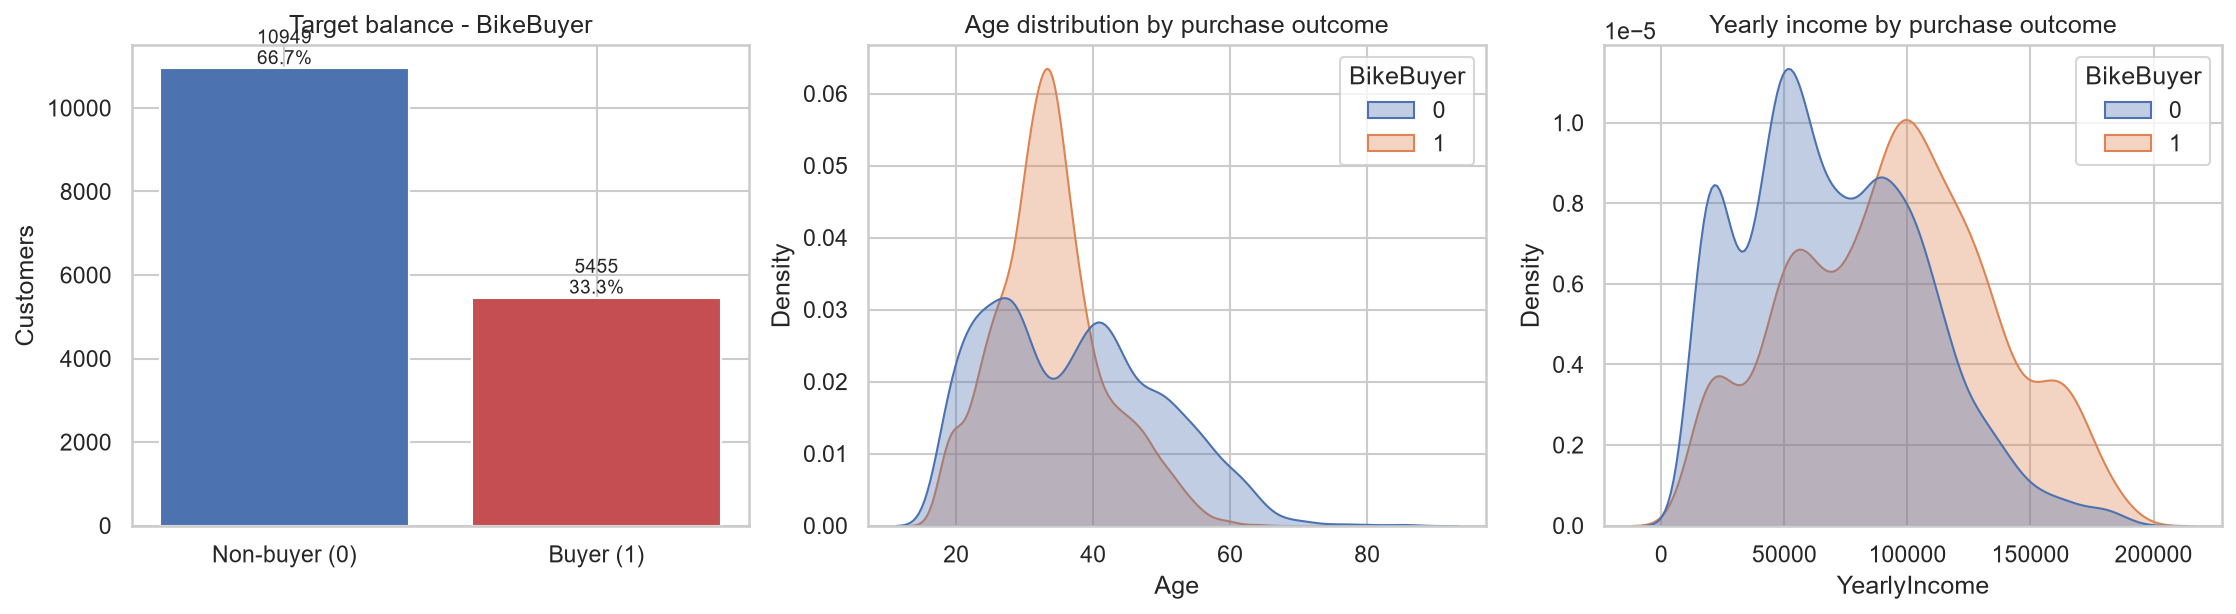

   [figure saved] outputs\figures\aw_fig02_purchase_rate_by_segment.png


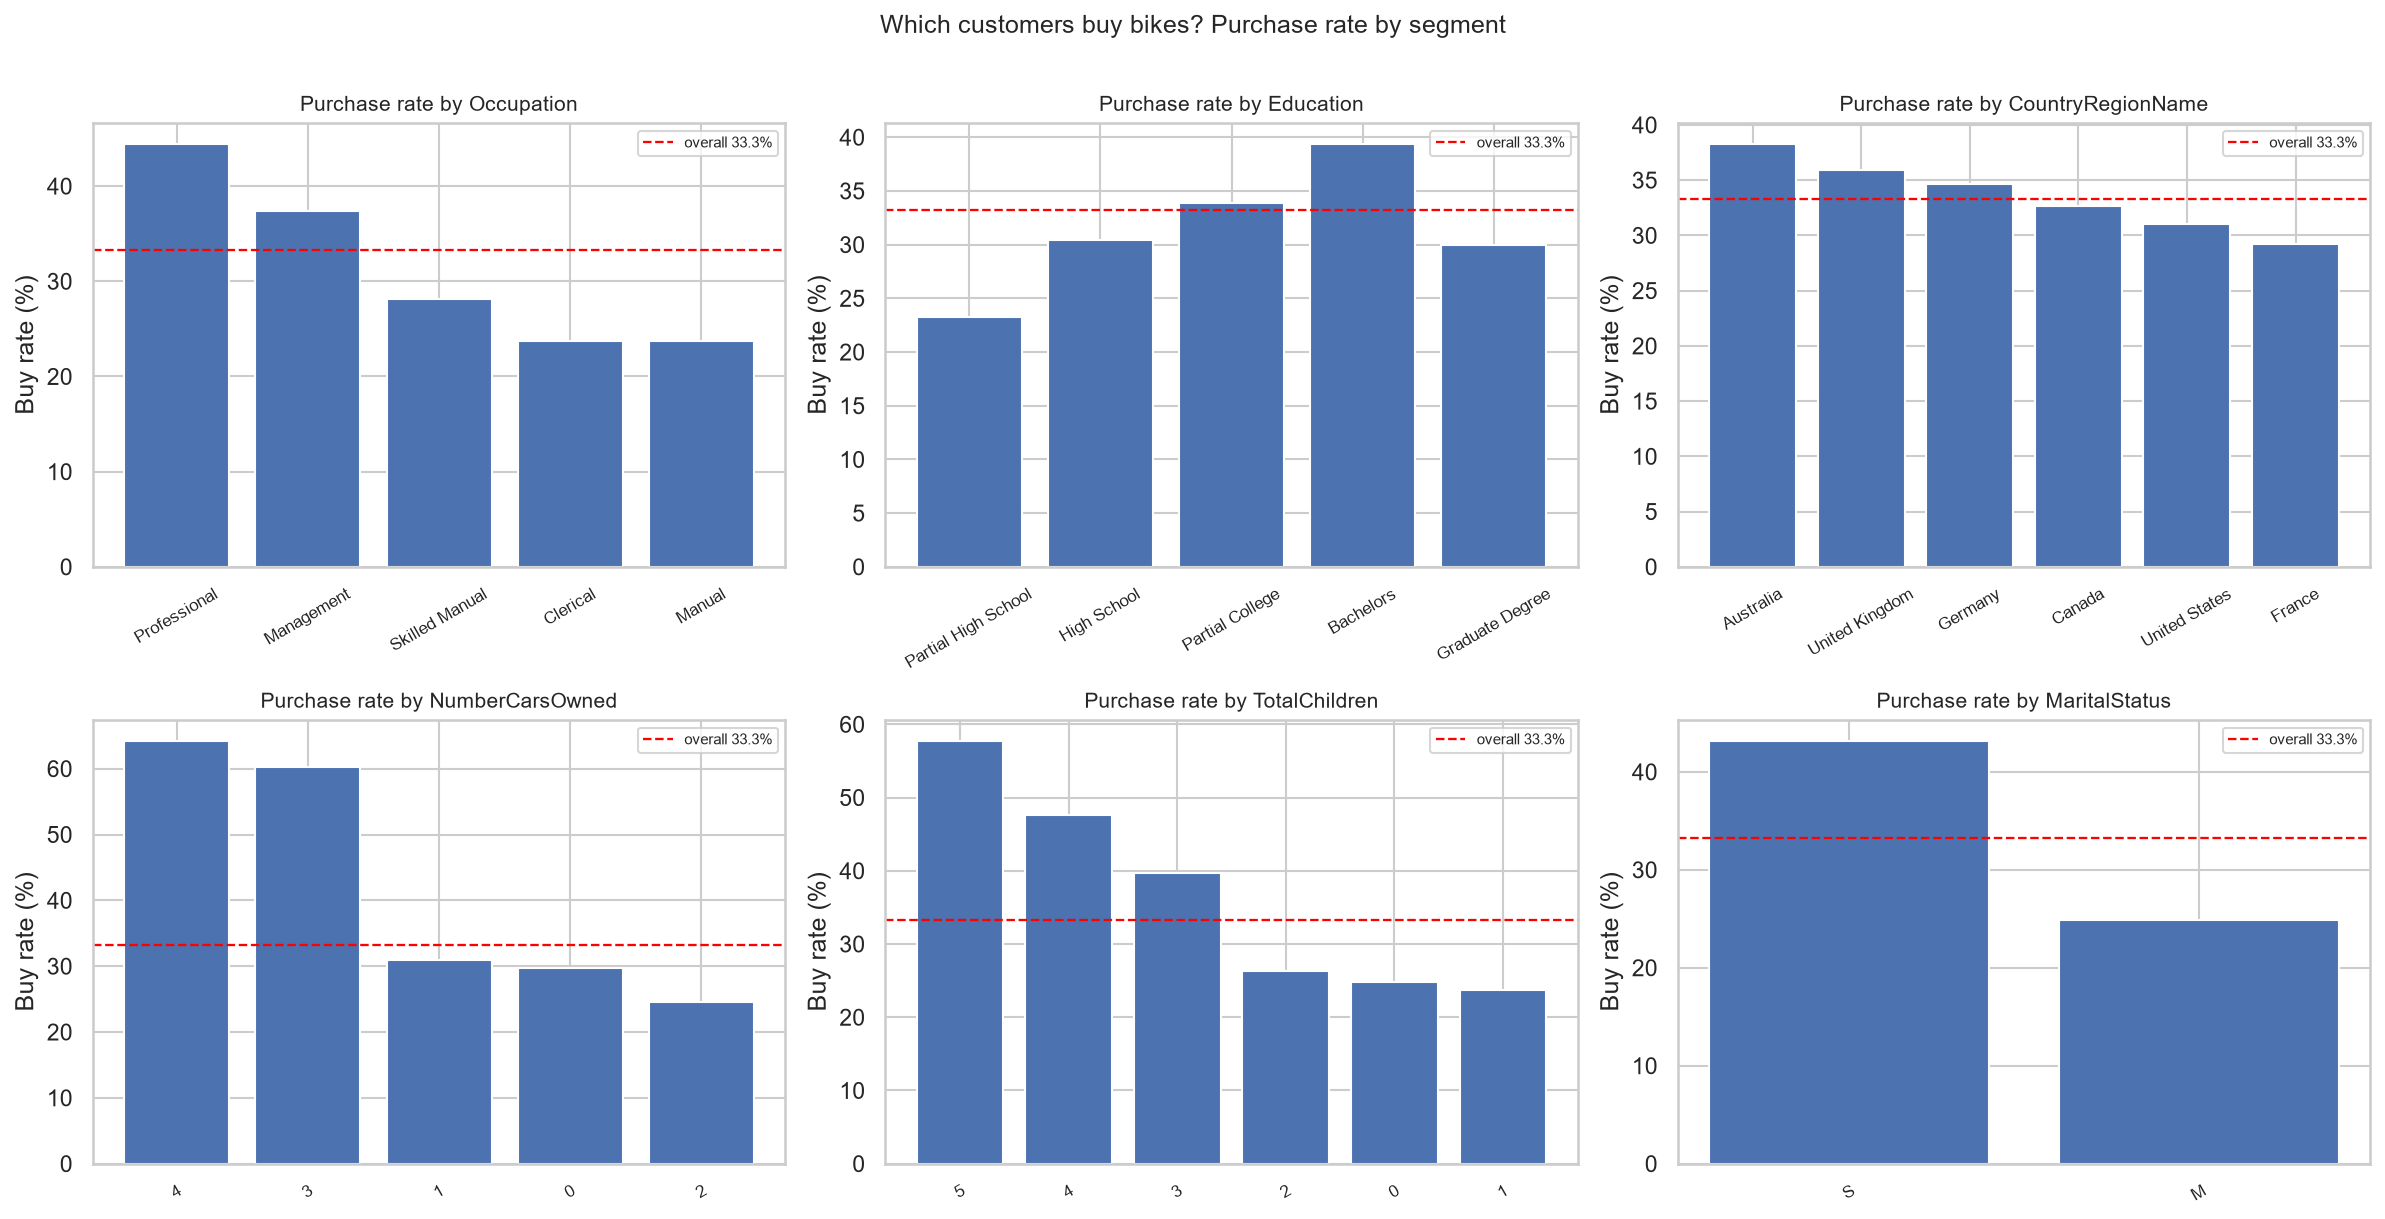

   [figure saved] outputs\figures\aw_fig03_segment_heatmap.png


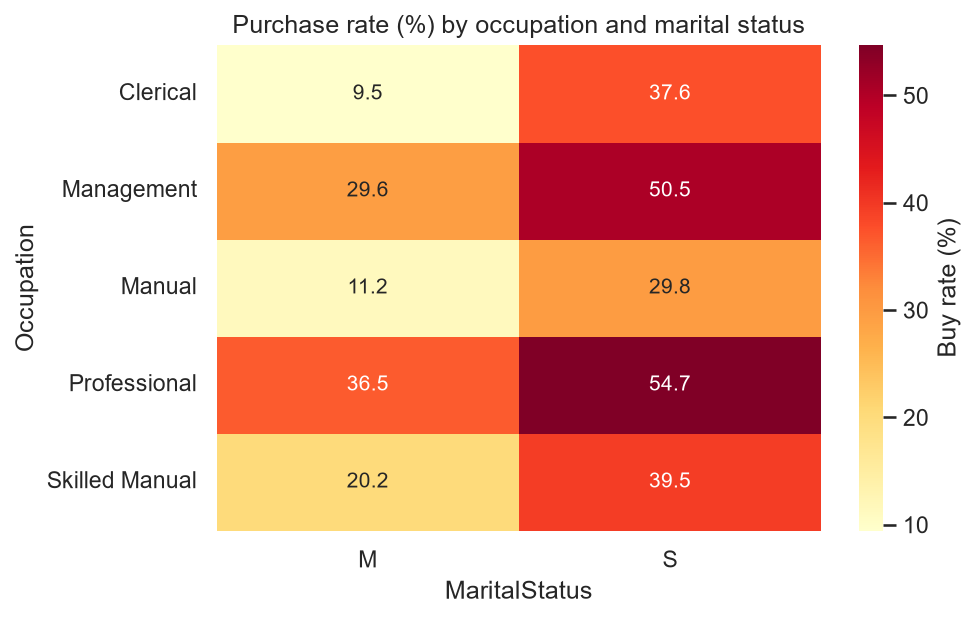

    Occupation  Customers  BuyRate  MedianIncome  MedianAge
  Professional       4922    44.37       99058.0  35.134839
    Management       2718    37.38      118781.0  48.147844
Skilled Manual       4038    28.11       66471.5  31.909651
      Clerical       2597    23.72       49481.0  35.236140
        Manual       2129    23.67       21722.0  29.264887
   [table saved ] outputs\tables\aw_t01_segment_profile.csv


In [3]:
# ============================================================================
# STEP 1 - DATASET PREPARATION
# ============================================================================
banner("STEP 1 | DATASET PREPARATION")

custs = pd.read_csv(os.path.join(DATA_DIR, "AdvWorksCusts.csv"))
buyer = pd.read_csv(os.path.join(DATA_DIR, "AW_BikeBuyer.csv"))
spend = pd.read_csv(os.path.join(DATA_DIR, "AW_AveMonthSpend.csv"))
print("Customers file : " + str(custs.shape))
print("BikeBuyer file : " + str(buyer.shape))
print("AveMonthSpend  : " + str(spend.shape))

# --- 1.1 Deduplication -------------------------------------------------------
# The raw extract ships with repeated CustomerIDs. Three cases exist and each
# needs a different answer, so a blanket drop_duplicates() would be wrong:
#   (a) exact duplicate rows            -> safe to drop
#   (b) same ID, conflicting attributes -> keep the last record
#   (c) same ID, conflicting target     -> keep the last record
# "Keep last" is applied consistently across all three tables so the customer,
# target and spend records stay aligned.
def dedupe(frame, label):
    n0 = len(frame)
    frame = frame.drop_duplicates()
    n1 = len(frame)
    conflicting = int(frame["CustomerID"].duplicated().sum())
    frame = frame.drop_duplicates(subset="CustomerID", keep="last")
    print("  " + label.ljust(14) + ": " + str(n0) + " rows -> " + str(n1)
          + " after exact-duplicate removal (" + str(n0 - n1) + " dropped) -> "
          + str(len(frame)) + " after resolving " + str(conflicting)
          + " conflicting IDs")
    return frame


print("Deduplication:")
custs = dedupe(custs, "customers")
buyer = dedupe(buyer, "bike buyer")
spend = dedupe(spend, "spend")

# --- 1.2 Join the three tables ----------------------------------------------
df = custs.merge(buyer, on="CustomerID", how="inner") \
          .merge(spend, on="CustomerID", how="inner")
print("Joined dataset : " + str(df.shape))
assert df["CustomerID"].is_unique, "CustomerID must be unique after dedup"

# --- 1.3 Drop identifiers and personally identifying columns ----------------
# These carry no generalisable signal: names and phone numbers are unique
# labels, and street address is too granular to learn from. Dropping them is
# both correct modelling practice and appropriate data handling.
DROP_PII = ["Title", "FirstName", "MiddleName", "LastName", "Suffix",
            "AddressLine1", "AddressLine2", "PhoneNumber", "City", "PostalCode"]
df = df.drop(columns=DROP_PII)
print("Dropped " + str(len(DROP_PII)) + " identifier / PII columns")

# StateProvinceName has 52 levels nested inside CountryRegionName (6 levels).
# One-hot encoding it would add 50+ sparse columns for little gain, so the
# coarser geography is kept.
df = df.drop(columns=["StateProvinceName"])

# --- 1.4 Clean categorical text ---------------------------------------------
# 'Bachelors ' carries a trailing space in the raw file and would otherwise
# encode as a separate level from 'Bachelors'.
text_cols = ["Education", "Occupation", "Gender", "MaritalStatus",
             "CountryRegionName"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()
print("Stripped whitespace from " + str(len(text_cols)) + " categorical columns")
print("  Education levels now: " + str(sorted(df["Education"].unique())))

# --- 1.5 Derived features ----------------------------------------------------
df["BirthDate"] = pd.to_datetime(df["BirthDate"])
df["Age"] = ((AGE_REFERENCE - df["BirthDate"]).dt.days / 365.25).round(1)
df = df.drop(columns=["BirthDate"])

# Behavioural ratios that the raw columns only imply
df["HasChildren"]        = (df["TotalChildren"] > 0).astype(int)
df["ChildrenAwayFromHome"] = (df["TotalChildren"] - df["NumberChildrenAtHome"]).clip(lower=0)
df["IncomePerChild"]     = df["YearlyIncome"] / (df["TotalChildren"] + 1)
df["CarsPerChild"]       = df["NumberCarsOwned"] / (df["TotalChildren"] + 1)
df["LogIncome"]          = np.log1p(df["YearlyIncome"])
df["IsSingle"]           = (df["MaritalStatus"] == "S").astype(int)

print("Age (as at " + str(AGE_REFERENCE.date()) + ") : "
      + format(df["Age"].min(), ".1f") + " - " + format(df["Age"].max(), ".1f")
      + " (median " + format(df["Age"].median(), ".1f") + ")")

# --- 1.6 Encoding ------------------------------------------------------------
# Education is ORDINAL - the levels have a natural order - so it is mapped to
# ranks rather than one-hot encoded, which preserves that ordering for the
# linear models and gives the trees a single split-able column.
edu_map = {lvl: i for i, lvl in enumerate(EDUCATION_ORDER)}
df["EducationRank"] = df["Education"].map(edu_map)
assert df["EducationRank"].notna().all(), "unmapped Education level"
print("Education ordinal-encoded: " + str(edu_map))

# The remaining categoricals are nominal -> one-hot
NOMINAL = ["Occupation", "Gender", "MaritalStatus", "CountryRegionName"]
df = pd.get_dummies(df, columns=NOMINAL, prefix=NOMINAL, drop_first=True)
dummy_cols = [c for c in df.columns
              if any(c.startswith(p + "_") for p in NOMINAL)]
df[dummy_cols] = df[dummy_cols].astype(int)
df = df.drop(columns=["Education"])
print("One-hot encoded " + str(len(NOMINAL)) + " nominal columns -> "
      + str(len(dummy_cols)) + " dummies")

print("\nTarget balance:")
vc = df[TARGET].value_counts()
print("  Non-buyers (0): " + str(vc[0]) + "  (" + format(vc[0] / len(df) * 100, ".2f") + "%)")
print("  Buyers     (1): " + str(vc[1]) + "  (" + format(vc[1] / len(df) * 100, ".2f") + "%)")
print("  Imbalance ratio: 1 : " + format(vc[0] / vc[1], ".2f"))
print("Final prepared shape: " + str(df.shape))


# --- 1.7 Exploratory analysis ------------------------------------------------
banner("STEP 1b | EXPLORATORY DATA ANALYSIS")

raw_cat = pd.read_csv(os.path.join(DATA_DIR, "AdvWorksCusts.csv")) \
            .drop_duplicates().drop_duplicates(subset="CustomerID", keep="last")
raw_cat["Education"] = raw_cat["Education"].str.strip()
eda = raw_cat.merge(buyer, on="CustomerID", how="inner")
eda["Age"] = ((AGE_REFERENCE - pd.to_datetime(eda["BirthDate"])).dt.days / 365.25)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
vc = eda[TARGET].value_counts().sort_index()
axes[0].bar(["Non-buyer (0)", "Buyer (1)"], vc.values,
            color=[sns.color_palette("deep")[0], sns.color_palette("deep")[3]])
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 100, str(v) + "\n" + format(v / len(eda) * 100, ".1f") + "%",
                 ha="center", fontsize=9)
axes[0].set_title("Target balance - BikeBuyer")
axes[0].set_ylabel("Customers")
sns.kdeplot(data=eda, x="Age", hue=TARGET, fill=True, common_norm=False,
            ax=axes[1], alpha=.35)
axes[1].set_title("Age distribution by purchase outcome")
sns.kdeplot(data=eda, x="YearlyIncome", hue=TARGET, fill=True, common_norm=False,
            ax=axes[2], alpha=.35)
axes[2].set_title("Yearly income by purchase outcome")
plt.tight_layout()
save_fig("aw_fig01_target_and_distributions.png")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plot_specs = [("Occupation", None), ("Education", EDUCATION_ORDER),
              ("CountryRegionName", None), ("NumberCarsOwned", None),
              ("TotalChildren", None), ("MaritalStatus", None)]
overall = eda[TARGET].mean()
for ax, (col, order) in zip(axes.ravel(), plot_specs):
    rate = eda.groupby(col)[TARGET].mean().sort_values(ascending=False)
    if order:
        rate = eda.groupby(col)[TARGET].mean().reindex(order)
    ax.bar([str(i) for i in rate.index], rate.values * 100,
           color=sns.color_palette("deep")[0])
    ax.axhline(overall * 100, ls="--", c="red", lw=1.1,
               label="overall " + format(overall * 100, ".1f") + "%")
    ax.set_title("Purchase rate by " + col, fontsize=10)
    ax.set_ylabel("Buy rate (%)")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.legend(fontsize=7)
plt.suptitle("Which customers buy bikes? Purchase rate by segment", y=1.01)
plt.tight_layout()
save_fig("aw_fig02_purchase_rate_by_segment.png")

seg = (eda.groupby(["Occupation", "MaritalStatus"])[TARGET]
          .agg(["mean", "size"]).reset_index())
pivot = seg.pivot(index="Occupation", columns="MaritalStatus", values="mean") * 100
fig, ax = plt.subplots(figsize=(6.5, 4.2))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd",
            cbar_kws={"label": "Buy rate (%)"}, ax=ax)
ax.set_title("Purchase rate (%) by occupation and marital status")
save_fig("aw_fig03_segment_heatmap.png")

seg_tbl = (eda.groupby("Occupation")
             .agg(Customers=(TARGET, "size"), BuyRate=(TARGET, "mean"),
                  MedianIncome=("YearlyIncome", "median"),
                  MedianAge=("Age", "median"))
             .assign(BuyRate=lambda d: (d["BuyRate"] * 100).round(2))
             .sort_values("BuyRate", ascending=False).reset_index())
print(seg_tbl.to_string(index=False))
save_table(seg_tbl, "aw_t01_segment_profile.csv")

---
### 2. Feature selection

> **`AveMonthSpend` is deliberately excluded.**

It records what a customer spends with Adventure Works, so it is measured contemporaneously with - and is partly *caused by* - the bike purchase itself. Including it would leak the outcome into the features, and it is unavailable at scoring time for a prospect who has not bought anything yet.

Three screens are then applied: a zero-variance filter, an `|r| > 0.95` redundancy filter, and a mutual-information ranking that captures non-linear dependence on the target.


STEP 2 | FEATURE SELECTION
Excluded as leakage : ['AveMonthSpend']
Candidate features  : 24
Removed (|corr| > 0.95) : ['MaritalStatus_S']
Final feature count     : 23



Top 12 features by mutual information:
                Feature  MutualInformation
   NumberChildrenAtHome           0.105786
                    Age           0.065226
           YearlyIncome           0.043367
              LogIncome           0.043116
        NumberCarsOwned           0.031525
          TotalChildren           0.027887
   ChildrenAwayFromHome           0.027374
               IsSingle           0.022495
           CarsPerChild           0.019929
Occupation_Professional           0.007227
          EducationRank           0.005308
      Occupation_Manual           0.005266
   [table saved ] outputs\tables\aw_t02_feature_mutual_information.csv


   [figure saved] outputs\figures\aw_fig04_feature_selection_mi.png


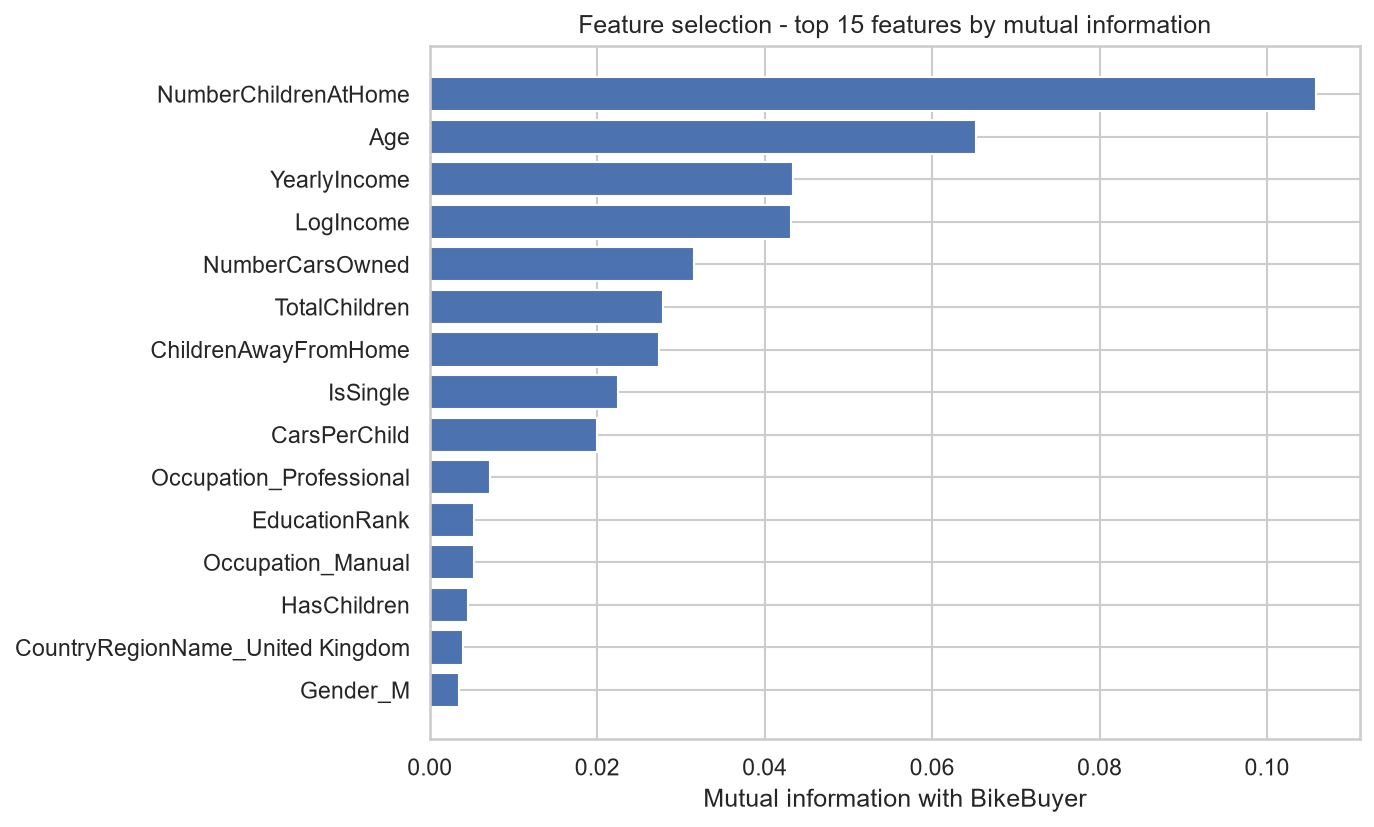

   [figure saved] outputs\figures\aw_fig05_correlation_matrix.png


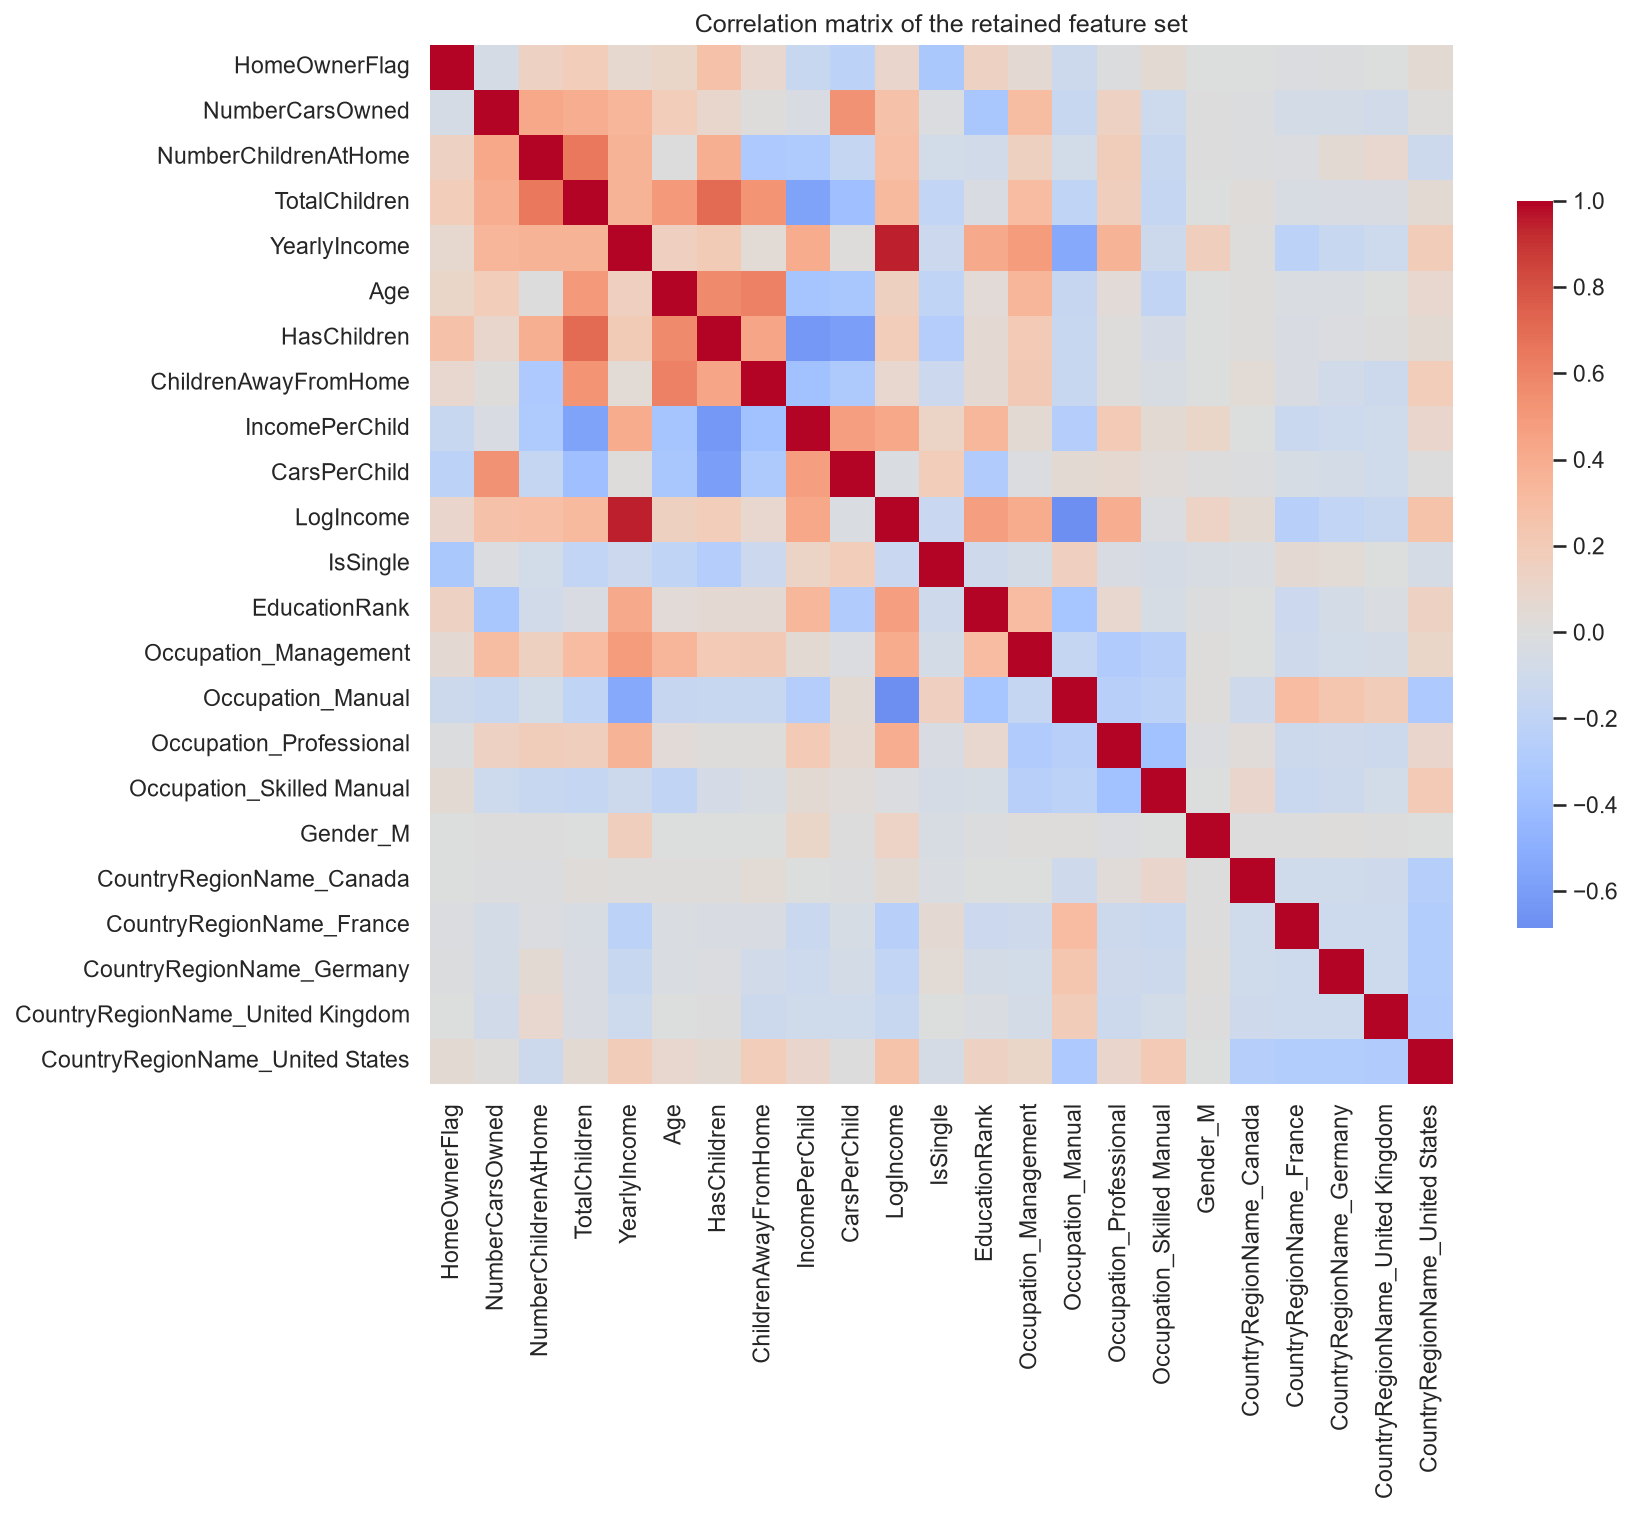

In [4]:
# ============================================================================
# STEP 2 - FEATURE SELECTION
# ============================================================================
banner("STEP 2 | FEATURE SELECTION")

# AveMonthSpend is deliberately EXCLUDED from the predictors. It records what a
# customer spends with Adventure Works, so it is measured contemporaneously
# with - and is partly caused by - the bike purchase itself. Including it would
# leak the outcome into the features, and it is unavailable at scoring time for
# a prospect who has not bought anything yet. This is the same class of mistake
# as the shuffled split corrected earlier in the programme.
LEAKY = ["AveMonthSpend"]
ID_COLS = ["CustomerID", TARGET] + LEAKY
print("Excluded as leakage : " + str(LEAKY))

candidate = [c for c in df.columns if c not in ID_COLS]
print("Candidate features  : " + str(len(candidate)))

# --- 2.1 Zero-variance filter ------------------------------------------------
variances = df[candidate].var()
low_var = variances[variances < 1e-8].index.tolist()
if low_var:
    print("Removed (zero variance) : " + str(low_var))
candidate = [c for c in candidate if c not in low_var]

# --- 2.2 Redundancy filter ---------------------------------------------------
corr = df[candidate].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
redundant = [c for c in upper.columns if any(upper[c] > 0.95)]
print("Removed (|corr| > 0.95) : " + str(redundant))
FEATURES = [c for c in candidate if c not in redundant]
print("Final feature count     : " + str(len(FEATURES)))

# --- 2.3 Mutual information --------------------------------------------------
mi = mutual_info_classif(df[FEATURES], df[TARGET], random_state=SEED)
mi_rank = (pd.DataFrame({"Feature": FEATURES, "MutualInformation": mi})
           .sort_values("MutualInformation", ascending=False).reset_index(drop=True))
print("\nTop 12 features by mutual information:")
print(mi_rank.head(12).to_string(index=False))
save_table(mi_rank.round(6), "aw_t02_feature_mutual_information.csv")

fig, ax = plt.subplots(figsize=(8, 6))
top_mi = mi_rank.head(15).iloc[::-1]
ax.barh(top_mi["Feature"], top_mi["MutualInformation"],
        color=sns.color_palette("deep")[0])
ax.set_title("Feature selection - top 15 features by mutual information")
ax.set_xlabel("Mutual information with BikeBuyer")
save_fig("aw_fig04_feature_selection_mi.png")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df[FEATURES].corr(), cmap="coolwarm", center=0,
            cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("Correlation matrix of the retained feature set")
save_fig("aw_fig05_correlation_matrix.png")

---
### 3. Stratified train / test split

This dataset is a **customer cross-section, not a time series**, so a random split is the correct choice here - there is no temporal ordering to violate. The split is **stratified** so that both partitions carry the same 33% buyer proportion, which matters when the classes are imbalanced.

In [5]:
# ============================================================================
# STEP 3 - TRAIN / TEST SPLIT
# ============================================================================
banner("STEP 3 | STRATIFIED TRAIN / TEST SPLIT")

X, y = df[FEATURES], df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print("This dataset is a customer cross-section, not a time series, so a")
print("random split is appropriate here - unlike a forecasting problem, where")
print("it would leak the future into the past. The split is STRATIFIED so that")
print("both partitions carry the same buyer proportion.\n")
print("TRAIN : " + str(X_train.shape[0]) + " rows | buy rate "
      + format(y_train.mean() * 100, ".2f") + "%")
print("TEST  : " + str(X_test.shape[0]) + " rows | buy rate "
      + format(y_test.mean() * 100, ".2f") + "%")

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)


STEP 3 | STRATIFIED TRAIN / TEST SPLIT
This dataset is a customer cross-section, not a time series, so a
random split is appropriate here - unlike a forecasting problem, where
it would leak the future into the past. The split is STRATIFIED so that
both partitions carry the same buyer proportion.

TRAIN : 13123 rows | buy rate 33.25%
TEST  : 3281 rows | buy rate 33.25%


---
### 4. Model training and evaluation metrics

**Why accuracy alone is the wrong metric.** 66.8% of customers do not buy, so a model that predicts "nobody buys" scores 66.8% accuracy while being completely useless - its F1 is 0.000 and its ROC-AUC is 0.500. Both baselines are scored explicitly to make this concrete.

| Metric | What it tells us |
|---|---|
| Accuracy | overall hit rate - reported, but never used alone |
| Balanced accuracy | mean recall across both classes |
| Precision | of those we mail, what share actually buy - drives campaign waste |
| Recall | of all buyers, what share we reach - drives missed revenue |
| **F1** | harmonic mean of the two |
| **ROC-AUC** | quality of the *ranking*, independent of any cut-off |
| **PR-AUC** | ranking quality focused on the minority class |

In [6]:
# ============================================================================
# STEP 4 - MODEL TRAINING AND EVALUATION METRICS
# ============================================================================
banner("STEP 4 | MODEL TRAINING (BASELINE + CANDIDATE MODELS)")


def evaluate(y_true, y_pred, y_proba):
    """Classification metrics appropriate to an imbalanced targeting problem."""
    return {
        "Accuracy":  float(accuracy_score(y_true, y_pred)),
        "BalancedAcc": float(balanced_accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "F1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "ROC_AUC":   float(roc_auc_score(y_true, y_proba)),
        "PR_AUC":    float(average_precision_score(y_true, y_proba)),
    }


results, probabilities, fitted = {}, {}, {}

# --- 4.1 Baselines -----------------------------------------------------------
# Majority-class: what "mail nobody" achieves. Its accuracy looks respectable
# purely because 66.8% of customers do not buy - which is exactly why accuracy
# alone is the wrong metric for this problem.
for label, strategy in [("Baseline - Majority Class", "most_frequent"),
                        ("Baseline - Stratified Random", "stratified")]:
    dummy = DummyClassifier(strategy=strategy, random_state=SEED)
    dummy.fit(X_train, y_train)
    proba = dummy.predict_proba(X_test)[:, 1]
    results[label] = evaluate(y_test, dummy.predict(X_test), proba)
    probabilities[label] = proba
    fitted[label] = (dummy, False)
    print(label.ljust(30) + " ->  Acc "
          + format(results[label]["Accuracy"], ".4f")
          + "  F1 " + format(results[label]["F1"], ".4f")
          + "  ROC-AUC " + format(results[label]["ROC_AUC"], ".4f"))

# --- 4.2 Candidate models ----------------------------------------------------
candidates = {
    "Logistic Regression": (LogisticRegression(max_iter=2000, random_state=SEED), True),
    "K-Nearest Neighbours": (KNeighborsClassifier(n_neighbors=25), True),
    "Decision Tree": (DecisionTreeClassifier(max_depth=8, random_state=SEED), False),
    "Random Forest": (RandomForestClassifier(n_estimators=400, random_state=SEED,
                                             n_jobs=-1), False),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=SEED), False),
    "HistGradientBoosting": (HistGradientBoostingClassifier(random_state=SEED), False),
}

for name, (model, needs_scaling) in candidates.items():
    Xtr = X_train_s if needs_scaling else X_train
    Xte = X_test_s if needs_scaling else X_test
    model.fit(Xtr, y_train)
    proba = model.predict_proba(Xte)[:, 1]
    results[name] = evaluate(y_test, model.predict(Xte), proba)
    probabilities[name] = proba
    fitted[name] = (model, needs_scaling)
    print(name.ljust(30) + " ->  Acc "
          + format(results[name]["Accuracy"], ".4f")
          + "  F1 " + format(results[name]["F1"], ".4f")
          + "  ROC-AUC " + format(results[name]["ROC_AUC"], ".4f")
          + "  PR-AUC " + format(results[name]["PR_AUC"], ".4f"))

untuned_tbl = pd.DataFrame(results).T.round(4)
untuned_tbl.index.name = "Model"
print("\nUntuned model comparison (20% stratified hold-out):")
print(untuned_tbl.to_string())
save_table(untuned_tbl.reset_index(), "aw_t03_untuned_model_comparison.csv")


STEP 4 | MODEL TRAINING (BASELINE + CANDIDATE MODELS)
Baseline - Majority Class      ->  Acc 0.6675  F1 0.0000  ROC-AUC 0.5000
Baseline - Stratified Random   ->  Acc 0.5376  F1 0.3038  ROC-AUC 0.4789
Logistic Regression            ->  Acc 0.7732  F1 0.6261  ROC-AUC 0.8295  PR-AUC 0.7249


K-Nearest Neighbours           ->  Acc 0.7863  F1 0.6479  ROC-AUC 0.8335  PR-AUC 0.7262
Decision Tree                  ->  Acc 0.7796  F1 0.6321  ROC-AUC 0.8341  PR-AUC 0.7227


Random Forest                  ->  Acc 0.7824  F1 0.6547  ROC-AUC 0.8301  PR-AUC 0.7243


Gradient Boosting              ->  Acc 0.7961  F1 0.6623  ROC-AUC 0.8576  PR-AUC 0.7749


HistGradientBoosting           ->  Acc 0.7952  F1 0.6627  ROC-AUC 0.8550  PR-AUC 0.7714

Untuned model comparison (20% stratified hold-out):
                              Accuracy  BalancedAcc  Precision  Recall      F1  ROC_AUC  PR_AUC
Model                                                                                          
Baseline - Majority Class       0.6675       0.5000     0.0000  0.0000  0.0000   0.5000  0.3325
Baseline - Stratified Random    0.5376       0.4789     0.3042  0.3034  0.3038   0.4789  0.3239
Logistic Regression             0.7732       0.7225     0.6930  0.5710  0.6261   0.8295  0.7249
K-Nearest Neighbours            0.7863       0.7374     0.7167  0.5912  0.6479   0.8335  0.7262
Decision Tree                   0.7796       0.7268     0.7105  0.5692  0.6321   0.8341  0.7227
Random Forest                   0.7824       0.7418     0.6929  0.6205  0.6547   0.8301  0.7243
Gradient Boosting               0.7961       0.7472     0.7371  0.6013  0.6623   0.8576  0.

---
### 5. Hyperparameter tuning

- **`RandomizedSearchCV`** - 25 sampled configurations per model, far more efficient than an exhaustive grid over this space.
- **Validation curves** - sweep one parameter at a time, plotting training against cross-validation AUC so the onset of over-fitting is visible.

**`StratifiedKFold`** preserves the 33/67 class ratio in every fold.

> **Why tune on ROC-AUC rather than accuracy?** The deliverable is a *ranking* of customers by propensity, which the campaign then cuts at whatever depth the budget allows. AUC scores that ranking directly and is independent of any single threshold.


STEP 5 | HYPERPARAMETER TUNING (RandomizedSearchCV + validation curves)


Random Forest  best CV ROC-AUC : 0.8588
Random Forest  best params     : {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth': 6, 'class_weight': None}


HistGB         best CV ROC-AUC : 0.8654
HistGB         best params     : {'min_samples_leaf': 40, 'max_leaf_nodes': 15, 'max_iter': 200, 'max_depth': 4, 'learning_rate': 0.03, 'l2_regularization': 0.0}
Random Forest (tuned)          ->  Acc 0.7888  F1 0.6433  ROC-AUC 0.8505


HistGradientBoosting (tuned)   ->  Acc 0.7998  F1 0.6703  ROC-AUC 0.8606
   [table saved ] outputs\tables\aw_t04_tuning_best_params.csv


   [figure saved] outputs\figures\aw_fig06_valcurve_rf_maxdepth.png


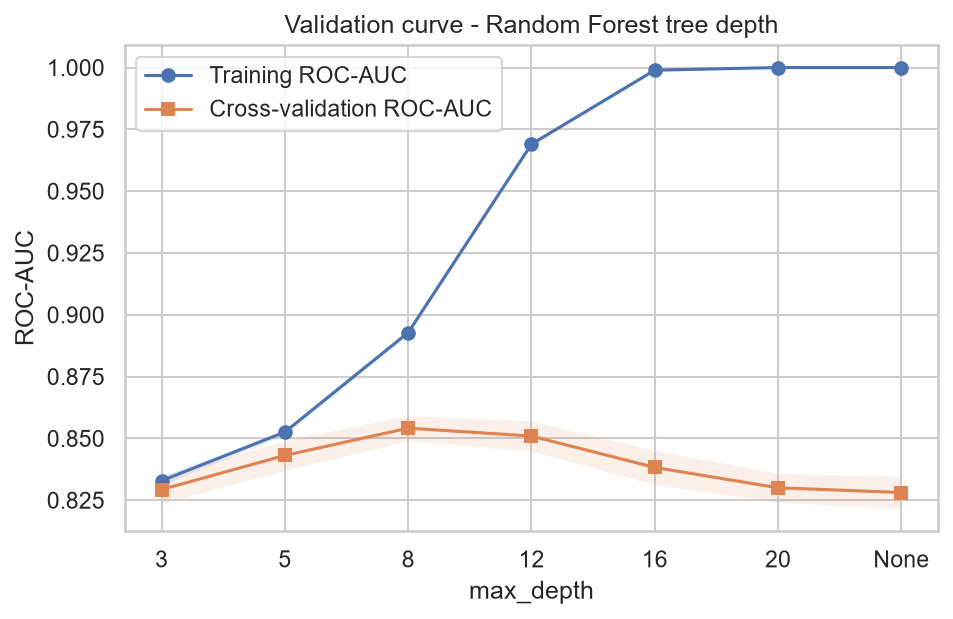

   [figure saved] outputs\figures\aw_fig07_valcurve_rf_minleaf.png


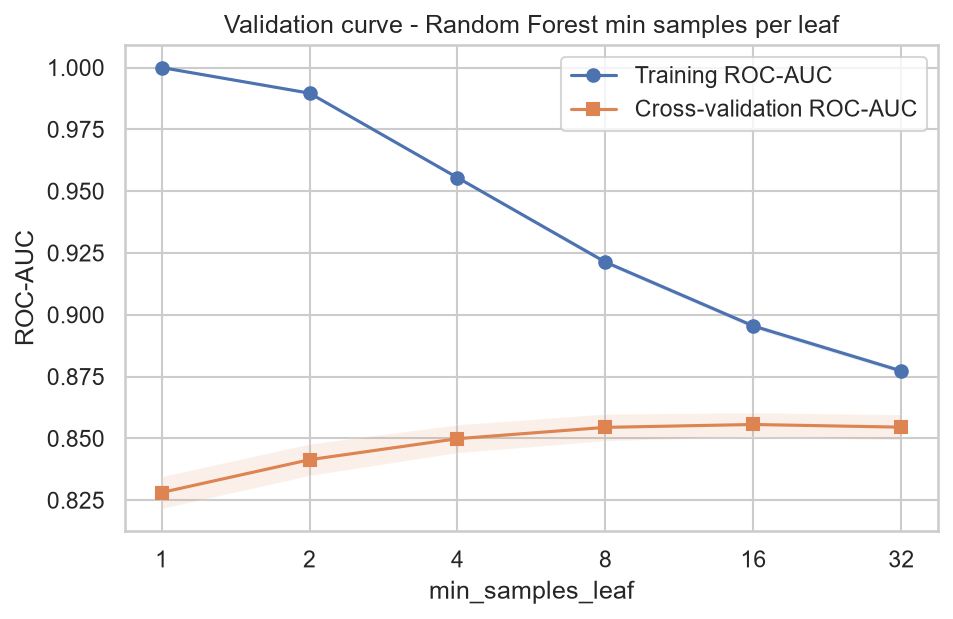

   [figure saved] outputs\figures\aw_fig08_valcurve_hgb_learningrate.png


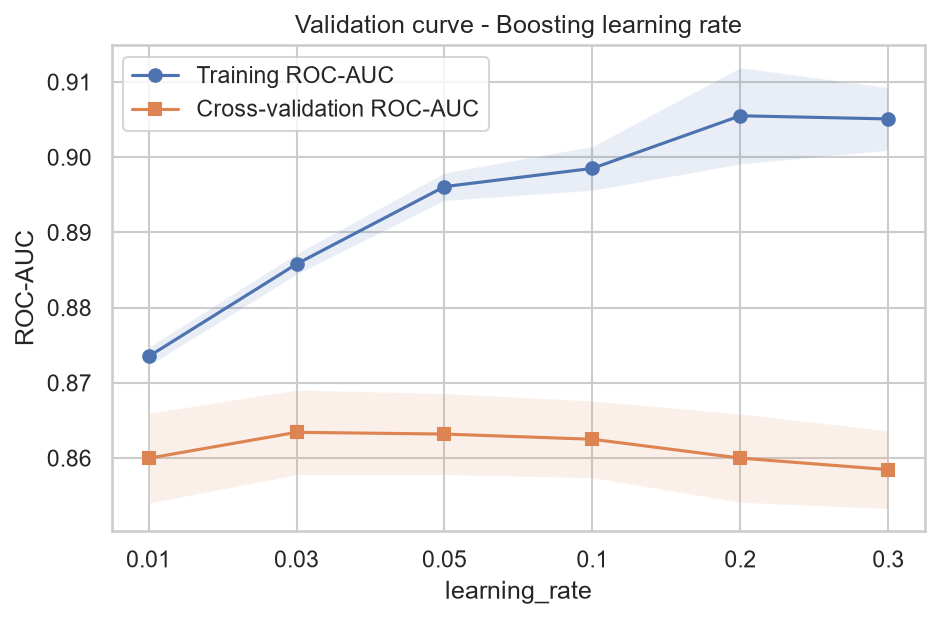

   [table saved ] outputs\tables\aw_t05_validation_curves.csv


In [7]:
# ============================================================================
# STEP 5 - HYPERPARAMETER TUNING
# ============================================================================
banner("STEP 5 | HYPERPARAMETER TUNING (RandomizedSearchCV + validation curves)")

# StratifiedKFold preserves the 33/67 class ratio in every fold, so no fold can
# be scored against an unrepresentative slice of buyers.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ROC-AUC is the tuning objective rather than accuracy: the deliverable is a
# RANKING of customers by propensity for campaign targeting, and AUC scores the
# quality of that ranking independently of any single cut-off.
rf_space = {
    "n_estimators":      [200, 400, 600],
    "max_depth":         [6, 10, 14, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf":  [1, 2, 4, 8],
    "max_features":      ["sqrt", "log2", 0.5],
    "class_weight":      [None, "balanced"],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    rf_space, n_iter=25, cv=skf, scoring="roc_auc",
    random_state=SEED, n_jobs=-1, verbose=0)
rf_search.fit(X_train, y_train)
print("Random Forest  best CV ROC-AUC : " + format(rf_search.best_score_, ".4f"))
print("Random Forest  best params     : " + str(rf_search.best_params_))

hgb_space = {
    "learning_rate":     [0.03, 0.05, 0.08, 0.1, 0.15],
    "max_iter":          [200, 300, 500],
    "max_depth":         [None, 4, 6, 8],
    "min_samples_leaf":  [10, 20, 40],
    "l2_regularization": [0.0, 0.1, 1.0],
    "max_leaf_nodes":    [15, 31, 63],
}
hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=SEED),
    hgb_space, n_iter=25, cv=skf, scoring="roc_auc",
    random_state=SEED, n_jobs=-1, verbose=0)
hgb_search.fit(X_train, y_train)
print("HistGB         best CV ROC-AUC : " + format(hgb_search.best_score_, ".4f"))
print("HistGB         best params     : " + str(hgb_search.best_params_))

for name, model in [("Random Forest (tuned)", rf_search.best_estimator_),
                    ("HistGradientBoosting (tuned)", hgb_search.best_estimator_)]:
    proba = model.predict_proba(X_test)[:, 1]
    results[name] = evaluate(y_test, model.predict(X_test), proba)
    probabilities[name] = proba
    fitted[name] = (model, False)
    print(name.ljust(30) + " ->  Acc "
          + format(results[name]["Accuracy"], ".4f")
          + "  F1 " + format(results[name]["F1"], ".4f")
          + "  ROC-AUC " + format(results[name]["ROC_AUC"], ".4f"))

save_table(pd.DataFrame([
    {"Model": "Random Forest", "BestCV_ROC_AUC": round(rf_search.best_score_, 4),
     "BestParams": json.dumps(rf_search.best_params_)},
    {"Model": "HistGradientBoosting", "BestCV_ROC_AUC": round(hgb_search.best_score_, 4),
     "BestParams": json.dumps(hgb_search.best_params_)},
]), "aw_t04_tuning_best_params.csv")


# --- 5.3 Validation curves ---------------------------------------------------
def plot_validation_curve(estimator, param_name, param_range, fname, title):
    tr, va = validation_curve(estimator, X_train, y_train,
                              param_name=param_name, param_range=param_range,
                              cv=skf, scoring="roc_auc", n_jobs=-1)
    tr_m, tr_s = tr.mean(axis=1), tr.std(axis=1)
    va_m, va_s = va.mean(axis=1), va.std(axis=1)
    xs = np.arange(len(param_range))
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.plot(xs, tr_m, "o-", label="Training ROC-AUC")
    ax.plot(xs, va_m, "s-", label="Cross-validation ROC-AUC")
    ax.fill_between(xs, tr_m - tr_s, tr_m + tr_s, alpha=0.12)
    ax.fill_between(xs, va_m - va_s, va_m + va_s, alpha=0.12)
    ax.set_xticks(xs)
    ax.set_xticklabels([str(p) for p in param_range])
    ax.set_xlabel(param_name)
    ax.set_ylabel("ROC-AUC")
    ax.set_title(title)
    ax.legend()
    save_fig(fname)
    return pd.DataFrame({"Curve": title, "Value": [str(p) for p in param_range],
                         "TrainAUC": tr_m.round(4), "CV_AUC": va_m.round(4)})


vc1 = plot_validation_curve(
    RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    "max_depth", [3, 5, 8, 12, 16, 20, None],
    "aw_fig06_valcurve_rf_maxdepth.png",
    "Validation curve - Random Forest tree depth")

vc2 = plot_validation_curve(
    RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    "min_samples_leaf", [1, 2, 4, 8, 16, 32],
    "aw_fig07_valcurve_rf_minleaf.png",
    "Validation curve - Random Forest min samples per leaf")

vc3 = plot_validation_curve(
    HistGradientBoostingClassifier(random_state=SEED),
    "learning_rate", [0.01, 0.03, 0.05, 0.1, 0.2, 0.3],
    "aw_fig08_valcurve_hgb_learningrate.png",
    "Validation curve - Boosting learning rate")

save_table(pd.concat([vc1, vc2, vc3], ignore_index=True),
           "aw_t05_validation_curves.csv")

---
### 6. Dimensionality reduction (PCA)

PCA is fitted on the standardised training matrix. The scree and cumulative variance plots show how many components retain 90% and 95% of the variance, and a two-component projection shows how separable the classes are in the reduced space. Logistic Regression and Random Forest are then retrained on the components, so PCA is kept or rejected on measured AUC rather than assumption.


STEP 6 | DIMENSIONALITY REDUCTION - PRINCIPAL COMPONENT ANALYSIS
Original dimensionality     : 23
Components for 90% variance : 13
Components for 95% variance : 15  (34.8% reduction)


   [figure saved] outputs\figures\aw_fig09_pca_explained_variance.png


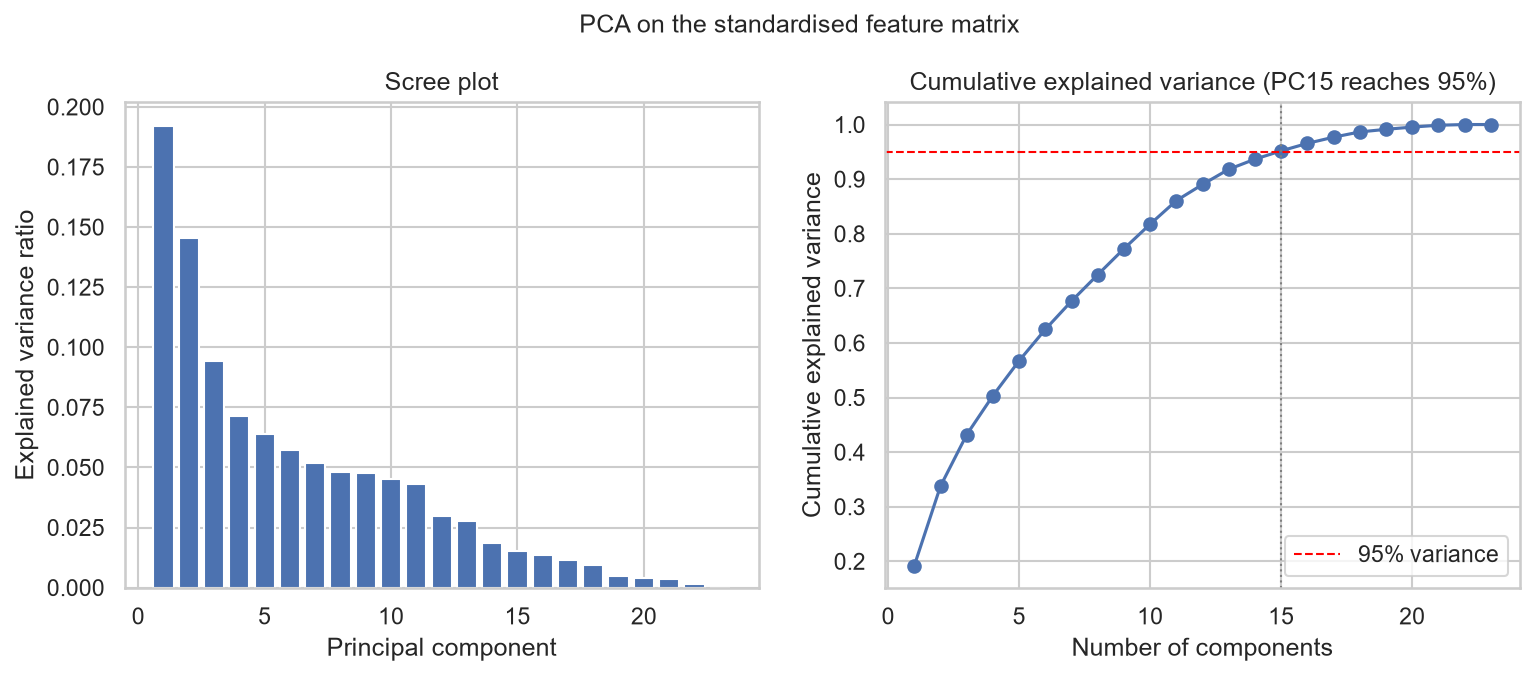

   [table saved ] outputs\tables\aw_t06_pca_explained_variance.csv


   [figure saved] outputs\figures\aw_fig10_pca_projection.png


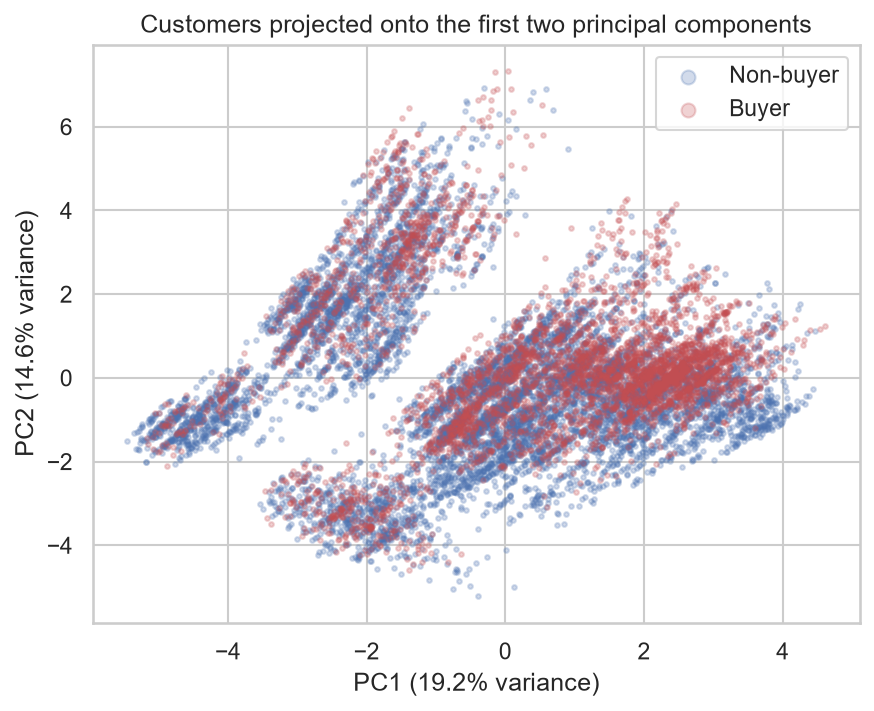

  PCA(13) + Logistic Regression      ->  ROC-AUC 0.8283  F1 0.6202


  PCA(13) + Random Forest            ->  ROC-AUC 0.8153  F1 0.6232
  PCA(15) + Logistic Regression      ->  ROC-AUC 0.8276  F1 0.6187


  PCA(15) + Random Forest            ->  ROC-AUC 0.8163  F1 0.6327
   [table saved ] outputs\tables\aw_t07_pca_model_comparison.csv

Best PCA variant retained in the master comparison: PCA(13) + Logistic Regression


In [8]:
# ============================================================================
# STEP 6 - DIMENSIONALITY REDUCTION (PCA)
# ============================================================================
banner("STEP 6 | DIMENSIONALITY REDUCTION - PRINCIPAL COMPONENT ANALYSIS")

pca_full = PCA(random_state=SEED).fit(X_train_s)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
n95 = int(np.argmax(cum >= 0.95) + 1)
n90 = int(np.argmax(cum >= 0.90) + 1)
print("Original dimensionality     : " + str(X_train_s.shape[1]))
print("Components for 90% variance : " + str(n90))
print("Components for 95% variance : " + str(n95)
      + "  (" + format(100 * (1 - n95 / X_train_s.shape[1]), ".1f") + "% reduction)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(np.arange(1, len(evr) + 1), evr, color=sns.color_palette("deep")[0])
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree plot")
axes[1].plot(np.arange(1, len(cum) + 1), cum, "o-")
axes[1].axhline(0.95, ls="--", c="red", lw=1, label="95% variance")
axes[1].axvline(n95, ls=":", c="grey", lw=1)
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative explained variance (PC" + str(n95) + " reaches 95%)")
axes[1].legend()
plt.suptitle("PCA on the standardised feature matrix", y=1.02)
save_fig("aw_fig09_pca_explained_variance.png")

save_table(pd.DataFrame({
    "Component": np.arange(1, len(evr) + 1),
    "ExplainedVarianceRatio": evr.round(5),
    "CumulativeVariance": cum.round(5)}), "aw_t06_pca_explained_variance.csv")

# --- 6.1 Two-component projection, coloured by outcome ----------------------
proj = PCA(n_components=2, random_state=SEED).fit_transform(X_train_s)
fig, ax = plt.subplots(figsize=(6.6, 5))
for cls, colour, lab in [(0, sns.color_palette("deep")[0], "Non-buyer"),
                         (1, sns.color_palette("deep")[3], "Buyer")]:
    m = (y_train.values == cls)
    ax.scatter(proj[m, 0], proj[m, 1], s=5, alpha=.25, c=[colour], label=lab)
ax.set_xlabel("PC1 (" + format(evr[0] * 100, ".1f") + "% variance)")
ax.set_ylabel("PC2 (" + format(evr[1] * 100, ".1f") + "% variance)")
ax.set_title("Customers projected onto the first two principal components")
ax.legend(markerscale=3)
save_fig("aw_fig10_pca_projection.png")

# --- 6.2 Retrain on the components ------------------------------------------
pca_results = {}
for n_comp in (n90, n95):
    pca = PCA(n_components=n_comp, random_state=SEED).fit(X_train_s)
    Ztr, Zte = pca.transform(X_train_s), pca.transform(X_test_s)
    for mdl_name, mdl in (("Logistic Regression",
                           LogisticRegression(max_iter=2000, random_state=SEED)),
                          ("Random Forest",
                           RandomForestClassifier(n_estimators=400,
                                                  random_state=SEED, n_jobs=-1))):
        mdl.fit(Ztr, y_train)
        proba = mdl.predict_proba(Zte)[:, 1]
        key = "PCA(" + str(n_comp) + ") + " + mdl_name
        pca_results[key] = evaluate(y_test, mdl.predict(Zte), proba)
        print("  " + key.ljust(34) + " ->  ROC-AUC "
              + format(pca_results[key]["ROC_AUC"], ".4f")
              + "  F1 " + format(pca_results[key]["F1"], ".4f"))

pca_tbl = pd.DataFrame(pca_results).T.round(4)
pca_tbl.index.name = "Model"
save_table(pca_tbl.reset_index(), "aw_t07_pca_model_comparison.csv")

best_pca_key = max(pca_results, key=lambda k: pca_results[k]["ROC_AUC"])
results[best_pca_key] = pca_results[best_pca_key]
print("\nBest PCA variant retained in the master comparison: " + best_pca_key)

---
### 7. Ensemble techniques

| Family | Model | Mechanism |
|---|---|---|
| Bagging | Random Forest | parallel trees on bootstrap samples |
| Boosting | Gradient Boosting / HistGradientBoosting | sequential trees, each correcting the last |
| Voting | `VotingClassifier` (soft) | averages predicted *probabilities*, preserving ranking information |
| Stacking | `StackingClassifier` | a logistic meta-model learns how to weight the base models |

> Note the contrast with a time-series problem: `StratifiedKFold` **does** partition the data, so scikit-learn's `StackingClassifier` can build its meta-features directly via `cross_val_predict`. A `TimeSeriesSplit` cannot, and would require a hand-built temporal stack.

In [9]:
# ============================================================================
# STEP 7 - ENSEMBLE TECHNIQUES
# ============================================================================
banner("STEP 7 | ENSEMBLE TECHNIQUES (Bagging / Boosting / Voting / Stacking)")

logit_pipe = Pipeline([("scaler", StandardScaler()),
                       ("model", LogisticRegression(max_iter=2000,
                                                    random_state=SEED))])

# Soft voting averages predicted probabilities rather than hard labels, which
# preserves the ranking information the campaign needs.
voting = VotingClassifier(estimators=[
    ("rf", rf_search.best_estimator_),
    ("hgb", hgb_search.best_estimator_),
    ("logit", logit_pipe),
], voting="soft", n_jobs=-1)
voting.fit(X_train, y_train)
proba = voting.predict_proba(X_test)[:, 1]
results["Voting Ensemble"] = evaluate(y_test, voting.predict(X_test), proba)
probabilities["Voting Ensemble"] = proba
fitted["Voting Ensemble"] = (voting, False)
print("Voting Ensemble    ->  ROC-AUC "
      + format(results["Voting Ensemble"]["ROC_AUC"], ".4f")
      + "  F1 " + format(results["Voting Ensemble"]["F1"], ".4f"))

# Unlike the time-series case, StratifiedKFold DOES partition the data, so
# scikit-learn's StackingClassifier can build its meta-features directly.
stacking = StackingClassifier(
    estimators=[
        ("rf", rf_search.best_estimator_),
        ("hgb", hgb_search.best_estimator_),
        ("logit", logit_pipe),
    ],
    final_estimator=LogisticRegression(max_iter=2000, random_state=SEED),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    stack_method="predict_proba",
    n_jobs=-1)
stacking.fit(X_train, y_train)
proba = stacking.predict_proba(X_test)[:, 1]
results["Stacking Ensemble"] = evaluate(y_test, stacking.predict(X_test), proba)
probabilities["Stacking Ensemble"] = proba
fitted["Stacking Ensemble"] = (stacking, False)
print("Stacking Ensemble  ->  ROC-AUC "
      + format(results["Stacking Ensemble"]["ROC_AUC"], ".4f")
      + "  F1 " + format(results["Stacking Ensemble"]["F1"], ".4f"))
print("Stacking meta weights : "
      + ", ".join(n + " " + format(w, ".3f") for n, w in
                  zip(["rf", "hgb", "logit"],
                      stacking.final_estimator_.coef_[0])))


STEP 7 | ENSEMBLE TECHNIQUES (Bagging / Boosting / Voting / Stacking)


Voting Ensemble    ->  ROC-AUC 0.8538  F1 0.6498


Stacking Ensemble  ->  ROC-AUC 0.8601  F1 0.6650
Stacking meta weights : rf 0.365, hgb 5.081, logit 0.359


---
### 8. Model comparison and final selection

Every model is ranked on hold-out ROC-AUC. Selection is justified on ranking quality first, then on F1, calibration and operational cost.


STEP 8 | FINAL MODEL COMPARISON AND SELECTION
                               Accuracy  BalancedAcc  Precision  Recall      F1  ROC_AUC  PR_AUC
Model                                                                                           
HistGradientBoosting (tuned)     0.7998       0.7527     0.7406  0.6123  0.6703   0.8606  0.7791
Stacking Ensemble                0.7973       0.7491     0.7383  0.6049  0.6650   0.8601  0.7780
Gradient Boosting                0.7961       0.7472     0.7371  0.6013  0.6623   0.8576  0.7749
HistGradientBoosting             0.7952       0.7475     0.7325  0.6049  0.6627   0.8550  0.7714
Voting Ensemble                  0.7891       0.7387     0.7254  0.5885  0.6498   0.8538  0.7650
Random Forest (tuned)            0.7888       0.7346     0.7336  0.5729  0.6433   0.8505  0.7629
Decision Tree                    0.7796       0.7268     0.7105  0.5692  0.6321   0.8341  0.7227
K-Nearest Neighbours             0.7863       0.7374     0.7167  0.5912  0.6479 

   [figure saved] outputs\figures\aw_fig11_model_comparison.png


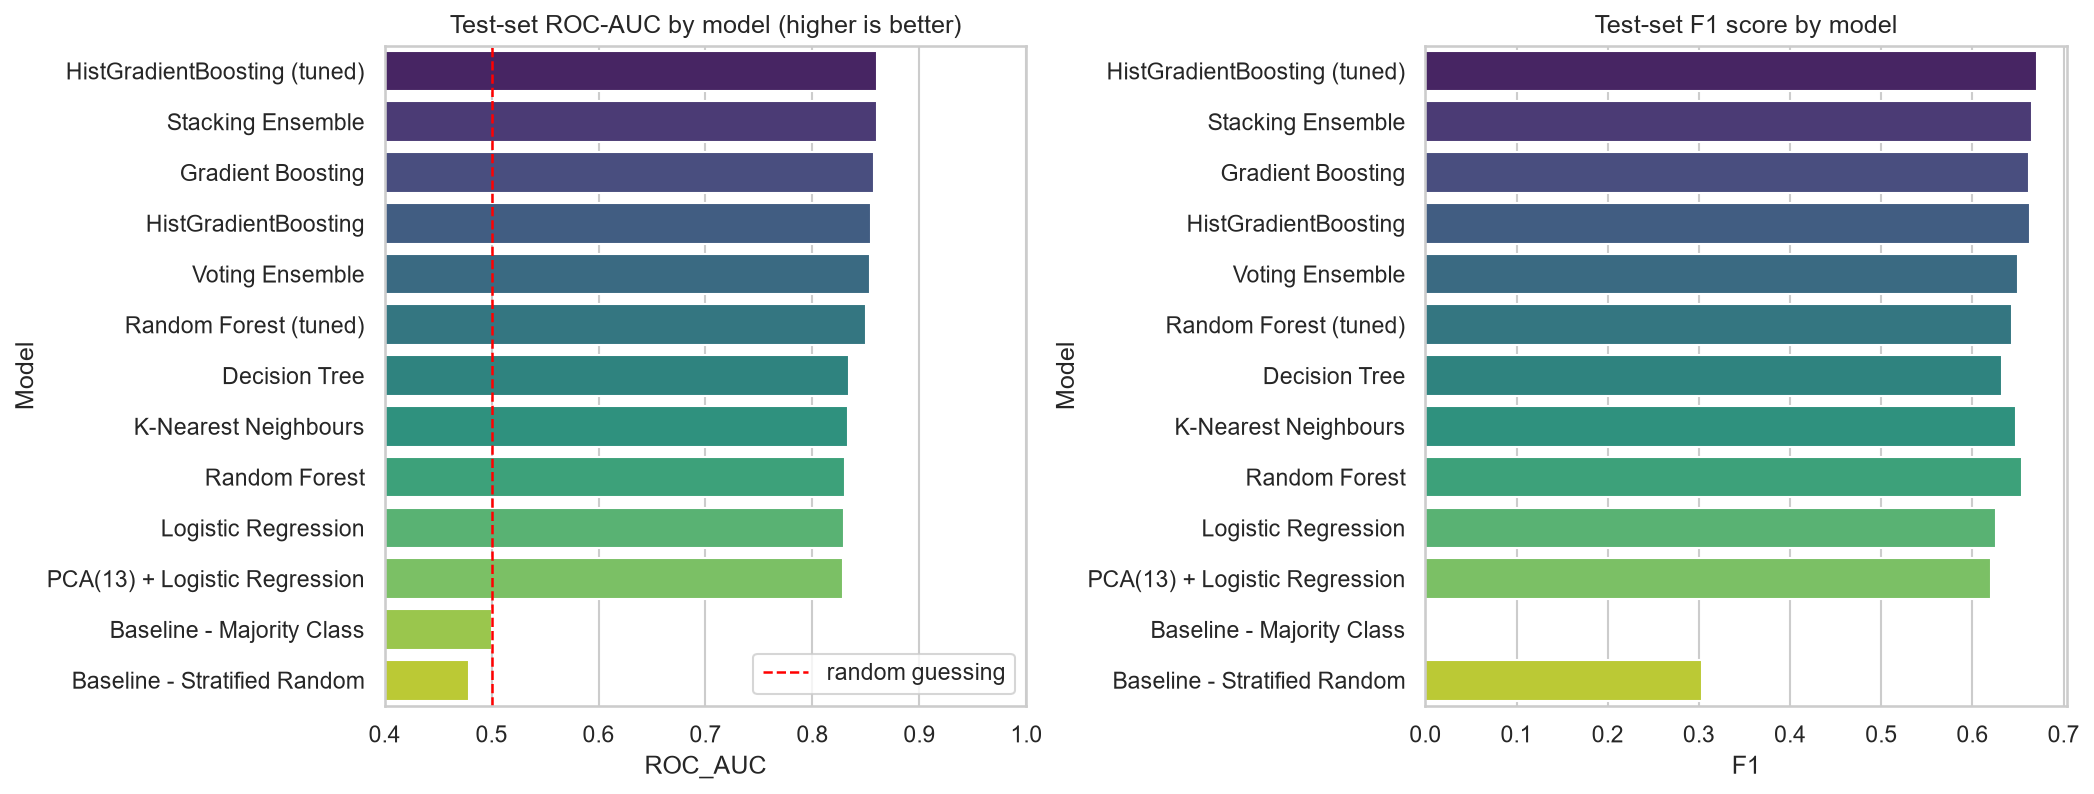

In [10]:
# ============================================================================
# STEP 8 - FINAL MODEL COMPARISON AND SELECTION
# ============================================================================
banner("STEP 8 | FINAL MODEL COMPARISON AND SELECTION")

final_tbl = pd.DataFrame(results).T.sort_values("ROC_AUC", ascending=False).round(4)
final_tbl.index.name = "Model"
print(final_tbl.to_string())
save_table(final_tbl.reset_index(), "aw_t08_final_model_comparison.csv")

BEST = final_tbl.index[0]
print("\nSELECTED MODEL: " + BEST)
for m in ["Accuracy", "F1", "ROC_AUC", "PR_AUC"]:
    print("  " + m.ljust(10) + format(final_tbl.loc[BEST, m], ".4f"))

plot_tbl = final_tbl.reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
sns.barplot(data=plot_tbl, y="Model", x="ROC_AUC", ax=axes[0],
            palette="viridis", hue="Model", legend=False)
axes[0].axvline(0.5, ls="--", c="red", lw=1.2, label="random guessing")
axes[0].set_xlim(0.4, 1.0)
axes[0].set_title("Test-set ROC-AUC by model (higher is better)")
axes[0].legend()
sns.barplot(data=plot_tbl, y="Model", x="F1", ax=axes[1],
            palette="viridis", hue="Model", legend=False)
axes[1].set_title("Test-set F1 score by model")
plt.tight_layout()
save_fig("aw_fig11_model_comparison.png")

---
### 9. Diagnostics and threshold optimisation

Four diagnostics: the confusion matrix, the ROC curve, the precision-recall curve (more informative than ROC under imbalance), and a **calibration curve** - which matters because the campaign uses predicted *probabilities*, not just labels, so those probabilities need to mean what they say.

> **The 0.50 cut-off is an arbitrary default, not a business decision.** Two alternatives are evaluated: the F1-optimal threshold, and the threshold that maximises expected campaign profit.


STEP 9 | DIAGNOSTICS FOR THE SELECTED MODEL

Classification report at the default 0.50 cut-off:
              precision    recall  f1-score   support

   Non-buyer     0.8222    0.8932    0.8562      2190
       Buyer     0.7406    0.6123    0.6703      1091

    accuracy                         0.7998      3281
   macro avg     0.7814    0.7527    0.7633      3281
weighted avg     0.7951    0.7998    0.7944      3281



   [figure saved] outputs\figures\aw_fig12_diagnostics.png


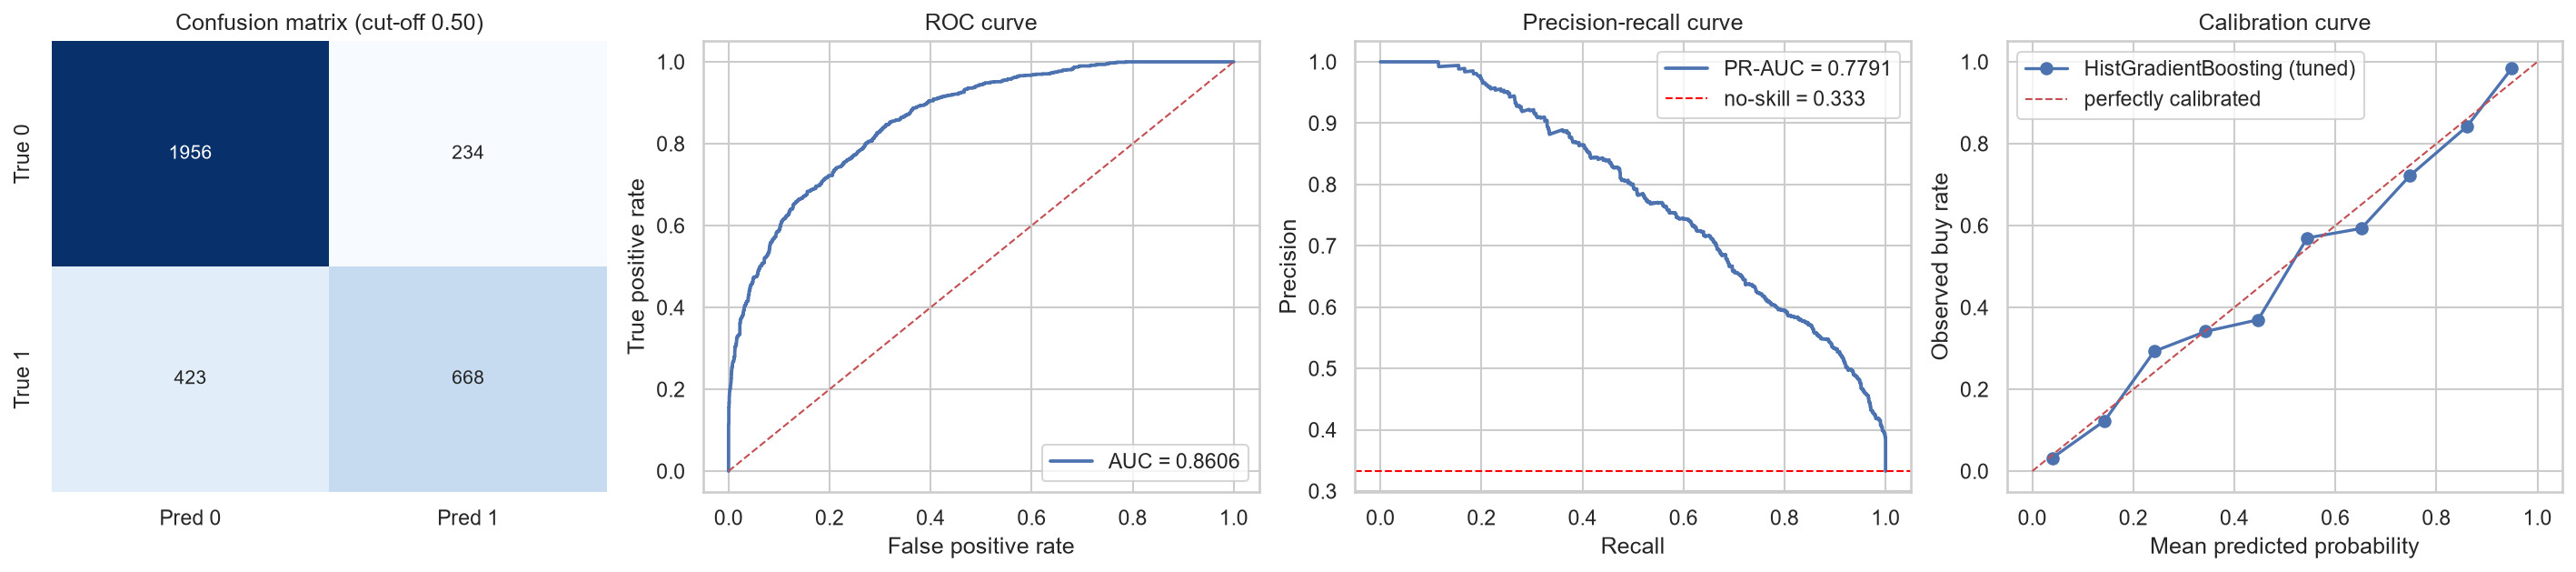

   [table saved ] outputs\tables\aw_t09_threshold_sweep.csv
Threshold analysis on the hold-out set:
  Default 0.500 -> F1 0.6703, profit 78,356
  F1-optimal 0.290 -> F1 0.6841, recall 0.8258, profit 105,034
  Profit-optimal 0.050 -> F1 0.5635, contacts 2778, profit 125,244


   [figure saved] outputs\figures\aw_fig13_threshold_optimisation.png


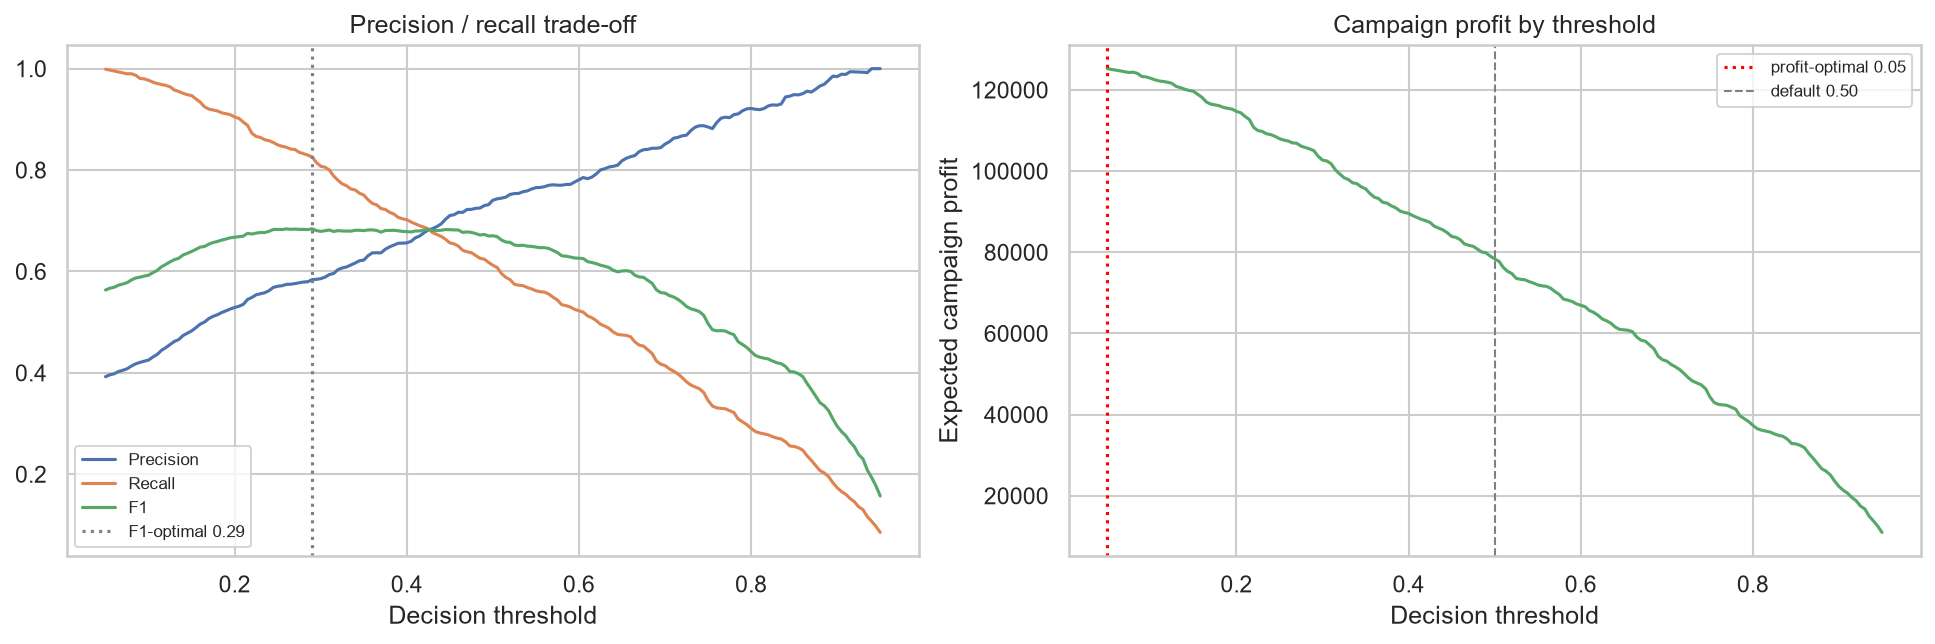


Top 12 features by permutation importance (drop in ROC-AUC):
                         Feature  Importance      Std
            NumberChildrenAtHome    0.137005 0.008011
                             Age    0.077895 0.004313
                        IsSingle    0.063251 0.003709
                        Gender_M    0.030136 0.001782
                    YearlyIncome    0.021276 0.002960
                   TotalChildren    0.000924 0.000408
CountryRegionName_United Kingdom    0.000642 0.000275
                 NumberCarsOwned    0.000444 0.000395
                    CarsPerChild    0.000402 0.000191
                  IncomePerChild    0.000316 0.000691
                   HomeOwnerFlag    0.000242 0.000045
         Occupation_Professional    0.000175 0.000147
   [table saved ] outputs\tables\aw_t10_permutation_importance.csv


   [figure saved] outputs\figures\aw_fig14_feature_importance.png


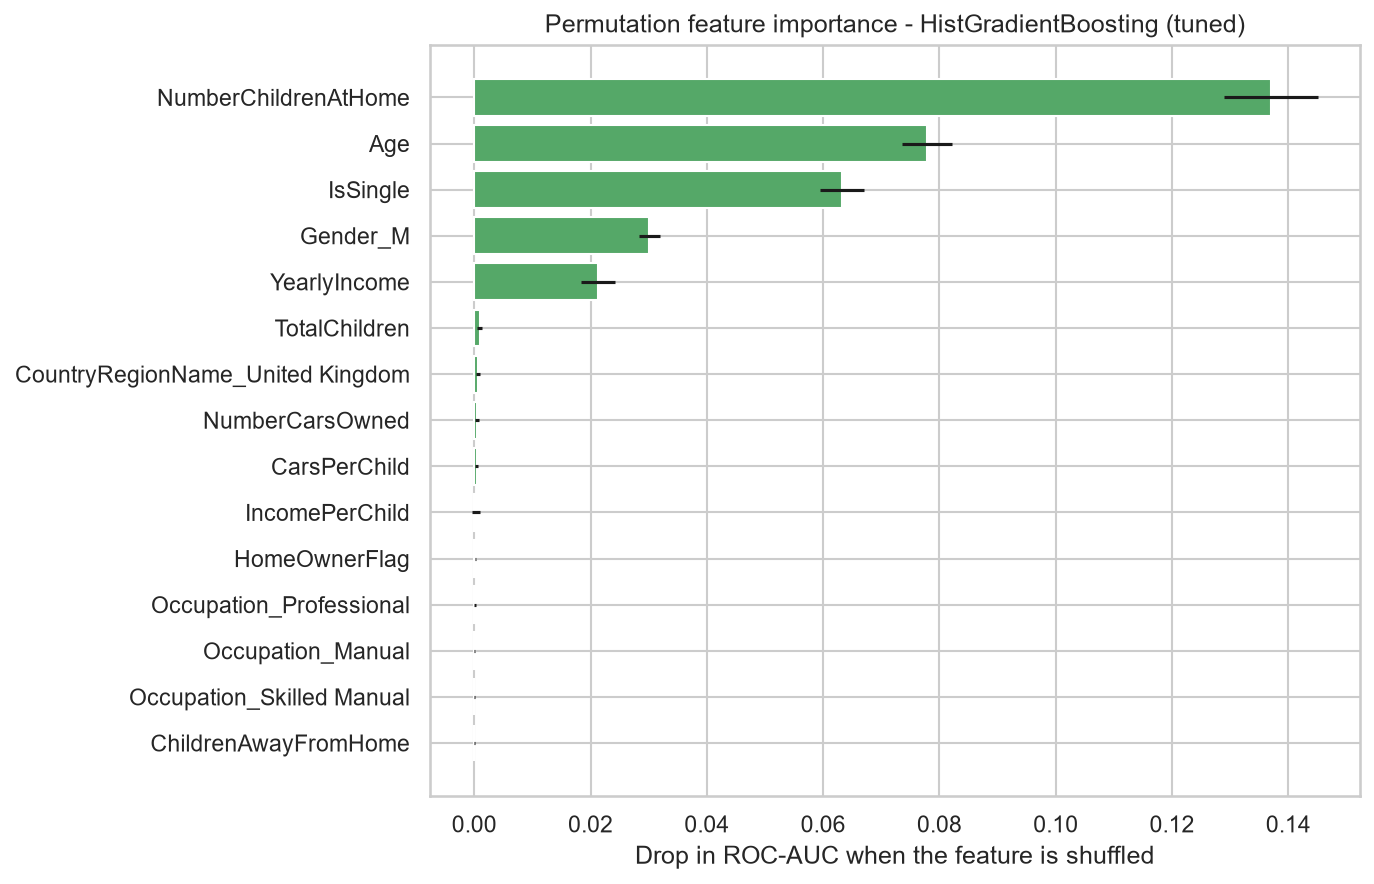

In [11]:
# ============================================================================
# STEP 9 - DIAGNOSTICS FOR THE SELECTED MODEL
# ============================================================================
banner("STEP 9 | DIAGNOSTICS FOR THE SELECTED MODEL")

DIAG = BEST if BEST in probabilities else max(
    probabilities, key=lambda k: results[k]["ROC_AUC"])
if DIAG != BEST:
    print("Note: '" + BEST + "' leads the table; diagnostics use '" + DIAG + "'.")
proba = np.asarray(probabilities[DIAG], dtype=float)
pred_default = (proba >= 0.5).astype(int)

print("\nClassification report at the default 0.50 cut-off:")
print(classification_report(y_test, pred_default,
                            target_names=["Non-buyer", "Buyer"], digits=4))

# --- 9.1 Confusion matrix, ROC, PR, calibration ------------------------------
cm = confusion_matrix(y_test, pred_default)
fpr, tpr, _ = roc_curve(y_test, proba)
prec, rec, pr_thresh = precision_recall_curve(y_test, proba)
frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"])
axes[0].set_title("Confusion matrix (cut-off 0.50)")

axes[1].plot(fpr, tpr, lw=1.8,
             label="AUC = " + format(results[DIAG]["ROC_AUC"], ".4f"))
axes[1].plot([0, 1], [0, 1], "r--", lw=1)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve")
axes[1].legend(loc="lower right")

axes[2].plot(rec, prec, lw=1.8,
             label="PR-AUC = " + format(results[DIAG]["PR_AUC"], ".4f"))
axes[2].axhline(y_test.mean(), ls="--", c="red", lw=1,
                label="no-skill = " + format(y_test.mean(), ".3f"))
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-recall curve")
axes[2].legend(loc="upper right")

axes[3].plot(mean_pred, frac_pos, "o-", lw=1.6, label=DIAG)
axes[3].plot([0, 1], [0, 1], "r--", lw=1, label="perfectly calibrated")
axes[3].set_xlabel("Mean predicted probability")
axes[3].set_ylabel("Observed buy rate")
axes[3].set_title("Calibration curve")
axes[3].legend(loc="upper left")
plt.tight_layout()
save_fig("aw_fig12_diagnostics.png")

# --- 9.2 Threshold optimisation ---------------------------------------------
# The 0.50 cut-off is an arbitrary default, not a business decision. Two
# alternatives are evaluated: the F1-optimal threshold, and the threshold that
# maximises expected campaign profit under the stated economics.
grid = np.linspace(0.05, 0.95, 181)
rows = []
for t in grid:
    p = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, p, labels=[0, 1]).ravel()
    rows.append({"Threshold": round(float(t), 3),
                 "Precision": precision_score(y_test, p, zero_division=0),
                 "Recall": recall_score(y_test, p, zero_division=0),
                 "F1": f1_score(y_test, p, zero_division=0),
                 "Contacted": int(tp + fp),
                 "Profit": tp * MARGIN_PER_SALE - (tp + fp) * COST_PER_CONTACT})
thr = pd.DataFrame(rows)
t_f1 = thr.loc[thr["F1"].idxmax()]
t_profit = thr.loc[thr["Profit"].idxmax()]
save_table(thr.round(4), "aw_t09_threshold_sweep.csv")

print("Threshold analysis on the hold-out set:")
print("  Default 0.500 -> F1 " + format(f1_score(y_test, pred_default), ".4f")
      + ", profit " + format(
          confusion_matrix(y_test, pred_default, labels=[0, 1]).ravel()[3]
          * MARGIN_PER_SALE
          - pred_default.sum() * COST_PER_CONTACT, ",.0f"))
print("  F1-optimal " + format(t_f1["Threshold"], ".3f")
      + " -> F1 " + format(t_f1["F1"], ".4f")
      + ", recall " + format(t_f1["Recall"], ".4f")
      + ", profit " + format(t_f1["Profit"], ",.0f"))
print("  Profit-optimal " + format(t_profit["Threshold"], ".3f")
      + " -> F1 " + format(t_profit["F1"], ".4f")
      + ", contacts " + str(int(t_profit["Contacted"]))
      + ", profit " + format(t_profit["Profit"], ",.0f"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].plot(thr["Threshold"], thr["Precision"], label="Precision")
axes[0].plot(thr["Threshold"], thr["Recall"], label="Recall")
axes[0].plot(thr["Threshold"], thr["F1"], label="F1")
axes[0].axvline(t_f1["Threshold"], ls=":", c="grey",
                label="F1-optimal " + format(t_f1["Threshold"], ".2f"))
axes[0].set_xlabel("Decision threshold")
axes[0].set_title("Precision / recall trade-off")
axes[0].legend(fontsize=8)
axes[1].plot(thr["Threshold"], thr["Profit"], c=sns.color_palette("deep")[2])
axes[1].axvline(t_profit["Threshold"], ls=":", c="red",
                label="profit-optimal " + format(t_profit["Threshold"], ".2f"))
axes[1].axvline(0.5, ls="--", c="grey", lw=1, label="default 0.50")
axes[1].set_xlabel("Decision threshold")
axes[1].set_ylabel("Expected campaign profit")
axes[1].set_title("Campaign profit by threshold")
axes[1].legend(fontsize=8)
plt.tight_layout()
save_fig("aw_fig13_threshold_optimisation.png")

# --- 9.3 Permutation feature importance -------------------------------------
from sklearn.inspection import permutation_importance

perm_model, perm_scaled = fitted[DIAG]
Xperm = X_test_s if perm_scaled else X_test
perm = permutation_importance(perm_model, Xperm, y_test, n_repeats=8,
                              random_state=SEED, n_jobs=-1, scoring="roc_auc")
imp = (pd.DataFrame({"Feature": FEATURES,
                     "Importance": perm.importances_mean,
                     "Std": perm.importances_std})
       .sort_values("Importance", ascending=False).reset_index(drop=True))
print("\nTop 12 features by permutation importance (drop in ROC-AUC):")
print(imp.head(12).to_string(index=False))
save_table(imp.round(6), "aw_t10_permutation_importance.csv")

fig, ax = plt.subplots(figsize=(8, 6.5))
top = imp.head(15).iloc[::-1]
ax.barh(top["Feature"], top["Importance"], xerr=top["Std"],
        color=sns.color_palette("deep")[2])
ax.set_xlabel("Drop in ROC-AUC when the feature is shuffled")
ax.set_title("Permutation feature importance - " + DIAG)
save_fig("aw_fig14_feature_importance.png")

---
### 10. Business interpretation

The model output is converted into a campaign decision through a **decile lift and gains analysis**: customers are ranked by predicted propensity, split into ten equal groups, and the buy rate in each is compared with the base rate.

A **sensitivity analysis** then tests how the value of targeting changes with campaign economics - because whether targeting pays turns out to be a property of the cost-to-margin ratio, not of the model.


STEP 10 | BUSINESS INTERPRETATION - CAMPAIGN TARGETING
 Decile  Customers  Buyers  BuyRate  MinProba  Lift  CumBuyers  CumCapture_%  Profit  CumProfit
      1        329     304    92.40  0.819602  2.78        304          27.9 35822.0    35822.0
      2        328     225    68.60  0.636999  2.06        529          48.5 26344.0    62166.0
      3        328     176    53.66  0.461110  1.61        705          64.6 20464.0    82630.0
      4        328     113    34.45  0.351009  1.04        818          75.0 12904.0    95534.0
      5        328     114    34.76  0.244801  1.05        932          85.4 13024.0   108558.0
      6        328      70    21.34  0.174362  0.64       1002          91.8  7744.0   116302.0
      7        328      48    14.63  0.125923  0.44       1050          96.2  5104.0   121406.0
      8        328      30     9.15  0.078481  0.28       1080          99.0  2944.0   124350.0
      9        328      11     3.35  0.025249  0.10       1091         100.0   6

   [figure saved] outputs\figures\aw_fig15_lift_gains_profit.png


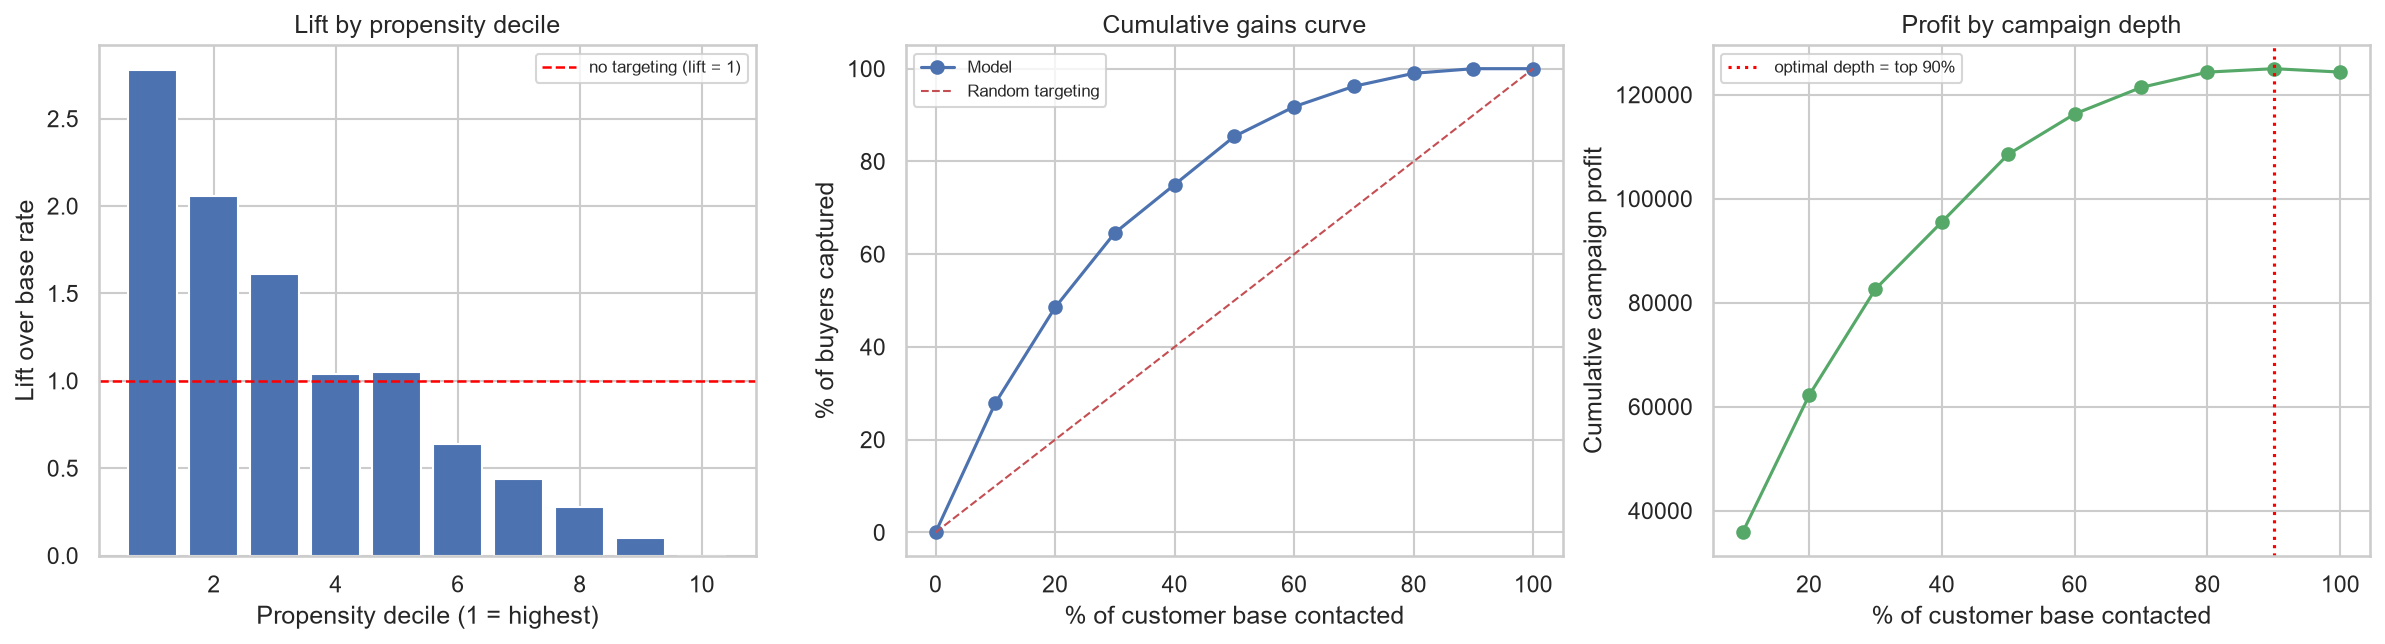


Campaign economics on the 3281-customer hold-out
(assumptions: margin per sale 120, cost per contact 2.00)

  Mail everyone      : 3281 contacts -> profit 124,358
  Model-targeted     : 2953 contacts (top 90%) -> profit 125,014
  Contacts avoided   : 328  (10.0% of the base)
  Top-decile lift    : 2.78x the base buy rate
  Buyers captured in the top 30%: 64.6%
   [table saved ] outputs\tables\aw_t12_campaign_economics.csv

            Metric  MailEveryone  ModelTargeted
     Contacts made        3281.0        2953.00
   Campaign profit      124358.0      125014.00
Profit per contact          37.9          42.33
   Top-decile lift           1.0           2.78

Break-even purchase probability = cost / margin = 1.67%
Share of hold-out customers above break-even: 92.5%

Sensitivity of targeting value to contact cost (margin held at 120):
 CostPerContact  BreakEvenProb_%  OptimalDepth_%  MailAllProfit  TargetedProfit  ProfitGain  Uplift_%
              1             0.83              90   

   [figure saved] outputs\figures\aw_fig16_targeting_sensitivity.png


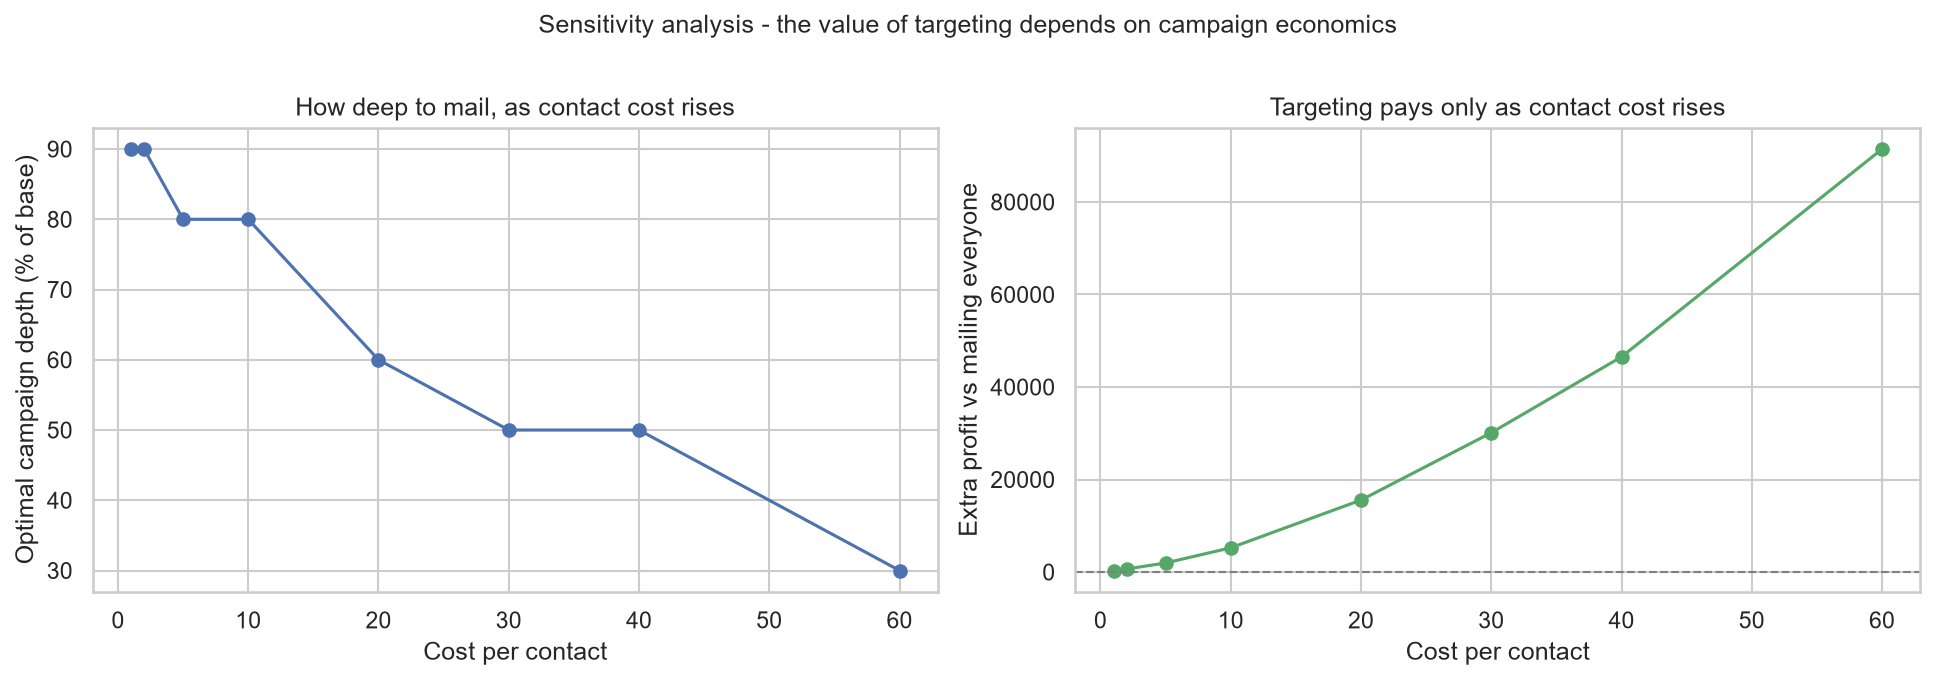

   [table saved ] outputs\tables\aw_t14_holdout_scores.csv

   [summary saved] outputs\tables\aw_t15_run_summary.json

PIPELINE COMPLETE
Figures : outputs\figures
Tables  : outputs\tables


In [12]:
# ============================================================================
# STEP 10 - BUSINESS INTERPRETATION
# ============================================================================
banner("STEP 10 | BUSINESS INTERPRETATION - CAMPAIGN TARGETING")

# --- 10.1 Decile / lift analysis --------------------------------------------
gains = pd.DataFrame({"proba": proba, "actual": y_test.values}) \
          .sort_values("proba", ascending=False).reset_index(drop=True)
gains["Decile"] = pd.qcut(gains.index, 10, labels=range(1, 11)).astype(int)
overall_rate = gains["actual"].mean()

dec = (gains.groupby("Decile")
       .agg(Customers=("actual", "size"), Buyers=("actual", "sum"),
            BuyRate=("actual", "mean"), MinProba=("proba", "min"))
       .reset_index())
dec["Lift"] = (dec["BuyRate"] / overall_rate).round(2)
dec["CumBuyers"] = dec["Buyers"].cumsum()
dec["CumCapture_%"] = (dec["CumBuyers"] / dec["Buyers"].sum() * 100).round(1)
dec["BuyRate"] = (dec["BuyRate"] * 100).round(2)
dec["Profit"] = (dec["Buyers"] * MARGIN_PER_SALE
                 - dec["Customers"] * COST_PER_CONTACT)
dec["CumProfit"] = dec["Profit"].cumsum()
print(dec.to_string(index=False))
save_table(dec, "aw_t11_decile_lift_analysis.csv")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
axes[0].bar(dec["Decile"], dec["Lift"], color=sns.color_palette("deep")[0])
axes[0].axhline(1.0, ls="--", c="red", lw=1.2, label="no targeting (lift = 1)")
axes[0].set_xlabel("Propensity decile (1 = highest)")
axes[0].set_ylabel("Lift over base rate")
axes[0].set_title("Lift by propensity decile")
axes[0].legend(fontsize=8)

axes[1].plot(np.arange(0, 11) * 10,
             np.concatenate([[0], dec["CumCapture_%"].values]), "o-",
             label="Model")
axes[1].plot([0, 100], [0, 100], "r--", lw=1, label="Random targeting")
axes[1].set_xlabel("% of customer base contacted")
axes[1].set_ylabel("% of buyers captured")
axes[1].set_title("Cumulative gains curve")
axes[1].legend(fontsize=8)

axes[2].plot(np.arange(1, 11) * 10, dec["CumProfit"], "o-",
             c=sns.color_palette("deep")[2])
best_depth = int(dec.loc[dec["CumProfit"].idxmax(), "Decile"]) * 10
axes[2].axvline(best_depth, ls=":", c="red",
                label="optimal depth = top " + str(best_depth) + "%")
axes[2].set_xlabel("% of customer base contacted")
axes[2].set_ylabel("Cumulative campaign profit")
axes[2].set_title("Profit by campaign depth")
axes[2].legend(fontsize=8)
plt.tight_layout()
save_fig("aw_fig15_lift_gains_profit.png")

# --- 10.2 Campaign economics -------------------------------------------------
n_test = len(y_test)
mail_all_profit = y_test.sum() * MARGIN_PER_SALE - n_test * COST_PER_CONTACT
best_row = dec.loc[dec["CumProfit"].idxmax()]
targeted_profit = float(best_row["CumProfit"])
contacts = int(dec.loc[dec["Decile"] <= best_row["Decile"], "Customers"].sum())

print("\nCampaign economics on the " + str(n_test) + "-customer hold-out")
print("(assumptions: margin per sale " + format(MARGIN_PER_SALE, ".0f")
      + ", cost per contact " + format(COST_PER_CONTACT, ".2f") + ")\n")
print("  Mail everyone      : " + str(n_test) + " contacts -> profit "
      + format(mail_all_profit, ",.0f"))
print("  Model-targeted     : " + str(contacts) + " contacts (top "
      + str(int(best_row["Decile"]) * 10) + "%) -> profit "
      + format(targeted_profit, ",.0f"))
print("  Contacts avoided   : " + str(n_test - contacts)
      + "  (" + format((n_test - contacts) / n_test * 100, ".1f") + "% of the base)")
print("  Top-decile lift    : " + format(dec.loc[0, "Lift"], ".2f")
      + "x the base buy rate")
print("  Buyers captured in the top 30%: "
      + format(dec.loc[2, "CumCapture_%"], ".1f") + "%")

biz = pd.DataFrame([
    {"Metric": "Contacts made", "MailEveryone": n_test, "ModelTargeted": contacts},
    {"Metric": "Campaign profit", "MailEveryone": round(mail_all_profit, 2),
     "ModelTargeted": round(targeted_profit, 2)},
    {"Metric": "Profit per contact",
     "MailEveryone": round(mail_all_profit / n_test, 2),
     "ModelTargeted": round(targeted_profit / max(contacts, 1), 2)},
    {"Metric": "Top-decile lift", "MailEveryone": 1.0,
     "ModelTargeted": float(dec.loc[0, "Lift"])},
])
save_table(biz, "aw_t12_campaign_economics.csv")
print("\n" + biz.to_string(index=False))

# --- 10.3 Sensitivity of targeting value to campaign economics --------------
# The result above is uncomfortable and worth stating plainly: at a margin of
# 120 against a contact cost of 2, a customer is worth mailing whenever their
# purchase probability exceeds break-even = cost / margin = 1.67%. Almost the
# entire base clears that bar, so blanket mailing is close to optimal and the
# model adds little PROFIT - though it still adds efficiency, since the same
# revenue is earned from 10% fewer contacts.
#
# Whether targeting pays is therefore a property of the economics, not of the
# model. This sweep shows where the crossover lies.
breakeven = COST_PER_CONTACT / MARGIN_PER_SALE
print("\nBreak-even purchase probability = cost / margin = "
      + format(breakeven * 100, ".2f") + "%")
print("Share of hold-out customers above break-even: "
      + format((proba > breakeven).mean() * 100, ".1f") + "%")

total_buyers = int(gains["actual"].sum())
sens_rows = []
for cost in [1, 2, 5, 10, 20, 30, 40, 60]:
    prof = dec["Buyers"] * MARGIN_PER_SALE - dec["Customers"] * cost
    cumprof = prof.cumsum()
    k = int(cumprof.idxmax())
    mail_all = total_buyers * MARGIN_PER_SALE - n_test * cost
    best = float(cumprof.iloc[k])
    sens_rows.append({
        "CostPerContact": cost,
        "BreakEvenProb_%": round(cost / MARGIN_PER_SALE * 100, 2),
        "OptimalDepth_%": int(dec.loc[k, "Decile"]) * 10,
        "MailAllProfit": round(mail_all, 0),
        "TargetedProfit": round(best, 0),
        "ProfitGain": round(best - mail_all, 0),
        # Percentage uplift is only meaningful while blanket mailing is still
        # profitable. Once MailAllProfit approaches or crosses zero the ratio
        # explodes or changes sign, so it is suppressed there and the absolute
        # ProfitGain column carries the comparison instead.
        "Uplift_%": round((best - mail_all) / mail_all * 100, 2)
        if mail_all > 0 else np.nan,
    })
sens = pd.DataFrame(sens_rows)
print("\nSensitivity of targeting value to contact cost (margin held at "
      + format(MARGIN_PER_SALE, ".0f") + "):")
print(sens.to_string(index=False))
save_table(sens, "aw_t13_targeting_sensitivity.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].plot(sens["CostPerContact"], sens["OptimalDepth_%"], "o-")
axes[0].set_xlabel("Cost per contact")
axes[0].set_ylabel("Optimal campaign depth (% of base)")
axes[0].set_title("How deep to mail, as contact cost rises")
axes[1].plot(sens["CostPerContact"], sens["ProfitGain"], "o-",
             c=sns.color_palette("deep")[2])
axes[1].axhline(0, ls="--", c="grey", lw=1)
axes[1].set_xlabel("Cost per contact")
axes[1].set_ylabel("Extra profit vs mailing everyone")
axes[1].set_title("Targeting pays only as contact cost rises")
plt.suptitle("Sensitivity analysis - the value of targeting depends on campaign economics",
             y=1.02)
plt.tight_layout()
save_fig("aw_fig16_targeting_sensitivity.png")

# Persist scored hold-out so downstream analysis needs no re-run
save_table(pd.DataFrame({"proba": proba, "actual": y_test.values}).round(6),
           "aw_t14_holdout_scores.csv")

summary = {
    "rows_after_dedup": int(len(df)),
    "features_used": len(FEATURES),
    "train_rows": int(len(X_train)), "test_rows": int(len(X_test)),
    "buy_rate_overall": round(float(df[TARGET].mean()), 4),
    "pca_components_for_95pct": n95,
    "selected_model": BEST,
    "diagnostics_model": DIAG,
    "test_Accuracy": round(results[DIAG]["Accuracy"], 4),
    "test_F1": round(results[DIAG]["F1"], 4),
    "test_ROC_AUC": round(results[DIAG]["ROC_AUC"], 4),
    "test_PR_AUC": round(results[DIAG]["PR_AUC"], 4),
    "f1_optimal_threshold": float(t_f1["Threshold"]),
    "profit_optimal_threshold": float(t_profit["Threshold"]),
    "top_decile_lift": float(dec.loc[0, "Lift"]),
    "capture_top30pct": float(dec.loc[2, "CumCapture_%"]),
    "optimal_campaign_depth_pct": int(best_row["Decile"]) * 10,
    "margin_per_sale_assumed": MARGIN_PER_SALE,
    "cost_per_contact_assumed": COST_PER_CONTACT,
    "breakeven_probability": round(float(breakeven), 5),
    "targeted_vs_mailall_uplift_pct": float(sens.loc[sens["CostPerContact"] == COST_PER_CONTACT, "Uplift_%"].iloc[0]),
}
with open(os.path.join(TAB_DIR, "aw_t15_run_summary.json"), "w") as fh:
    json.dump(summary, fh, indent=2)
print("\n   [summary saved] " + os.path.join(TAB_DIR, "aw_t15_run_summary.json"))

banner("PIPELINE COMPLETE")
print("Figures : " + FIG_DIR)
print("Tables  : " + TAB_DIR)

---
## Outputs

Figures are written to `outputs/figures/` and result tables to `outputs/tables/`. `aw_t15_run_summary.json` holds the headline numbers quoted in the progress report.